In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline,
    riskfolio_hrp,
    riskfolio_hrp_with_variants,
    portfolio_stats
)

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Portfolio Optimization using Hierarchical Risk Parity (HRP)

In [2]:
# Create a logger
logger = logging.getLogger("hrp_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


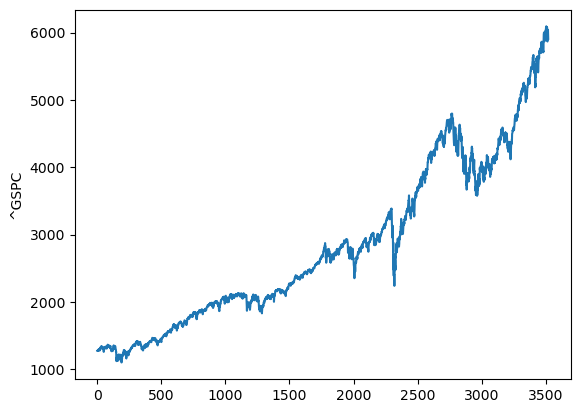

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Data generator

Data generator to instantiate blocks on demand

In [6]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # defining a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [7]:
def backtest(optimization_function, data, benchmark, initial_capital, avg_period, opt_period):
    portfolio_value = initial_capital
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value

    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        df = data.iloc[j:i, :]
        # Use log returns for consistency
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        
        weights = optimization_function(df)
        weights[weights < 0] = 0
        weights /= weights.sum()
        weights_history.loc[df.index[-1]] = weights
        
        portfolio_change = df_log_returns.iloc[-1] * weights
        portfolio_return = portfolio_change.sum()
        portfolio_returns.append(portfolio_return)
        
        # Use log returns for benchmark as well
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        benchmark_returns.append(benchmark_return)
        
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
        except Exception as e:
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

        # Portfolio & Benchmark value
        benchmark_value = initial_capital * benchmark_cumulative_returns[-1]
        portfolio_value = initial_capital * portfolio_cumulative_returns[-1]
        j += 1

    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]

    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results - HRP')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

### Pickle utilities

In [8]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    return loaded_dict

### Run Experiment Function

In [9]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):
    import traceback

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    initial_capital = parameters['initial_capital']
    datagen = generate_data(data, benchmark)

    for i in range(n_periods):
        results_path = results_path_template.format(i)
        if not os.path.exists(results_path):
            try:
                df, df_b = next(datagen)
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                
                start_time = datetime.now()
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(
                    opt_fun, df, df_b, initial_capital=initial_capital, avg_period=days_to_avg, opt_period=days_to_opt
                )
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                end_time = datetime.now()
                dt = abs(end_time - start_time)
            except Exception as e: 
                print(f'Failed {results_path} due to {e}')
                print("\nFull traceback:")
                print("=" * 80)
                traceback.print_exc()
                print("=" * 80)
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []
                dt = timedelta(0)

            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
            }
            write_pickle_dict(result, results_path)

        else:
            results = read_pickle_dict(results_path)
            if results is None:
                continue
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']

            # Plot the results
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results - HRP')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()
            
    return None

### Comparison functions

In [10]:
def multi_comparison(solver_configs, n_periods, title_prefix="HRP Portfolio Optimization", show_benchmark=True):
    """Compare multiple HRP variants across periods."""
    
    for period in range(n_periods):
        period_data = []
        benchmark_data = None
        
        # Load data for all solvers for this period
        for config in solver_configs:
            path_template = config['path_template']
            solver_name = config['name']
            file_path = path_template.format(period)
            
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
                    start_date = result_data.get('start_date', 'Unknown')
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Check if portfolio_returns has data
                    has_portfolio_data = False
                    if portfolio_returns is not None:
                        try:
                            has_portfolio_data = len(portfolio_returns) > 0
                        except TypeError:
                            has_portfolio_data = portfolio_returns is not None
                    
                    if has_portfolio_data:
                        period_data.append({
                            'name': solver_name,
                            'portfolio_returns': portfolio_returns,
                            'benchmark_returns': benchmark_returns,
                            'start_date': start_date,
                            'execution_time': execution_time,
                            'file_path': file_path
                        })
                        
                        if benchmark_data is None and benchmark_returns is not None:
                            try:
                                if len(benchmark_returns) > 0:
                                    benchmark_data = benchmark_returns
                            except (TypeError, AttributeError):
                                pass
                        
                        logger.info(f'Period {period}: Loaded {solver_name} (exec_time: {execution_time:.2f}s)')
                    else:
                        logger.warning(f'Period {period}: {solver_name} has no portfolio returns data')
                else:
                    logger.warning(f'Period {period}: Could not load {solver_name} from {file_path}')
                    
            except Exception as e:
                logger.error(f'Period {period}: Error loading {solver_name} from {file_path}: {e}')
        
        # Plot results if we have any data
        if period_data:
            plt.figure(figsize=(15, 8))
            colors = plt.cm.Set1(np.linspace(0, 1, len(period_data)))
            
            for i, data in enumerate(period_data):
                plt.plot(data['portfolio_returns'], 
                        label=f"{data['name']} (t={data['execution_time']:.1f}s)", 
                        color=colors[i], 
                        linewidth=2, 
                        alpha=0.8)
            
            if show_benchmark and benchmark_data is not None:
                plt.plot(benchmark_data, 
                        label='S&P 500 Benchmark', 
                        linestyle='--', 
                        color='black', 
                        linewidth=2, 
                        alpha=0.7)
            
            plt.title(f'{title_prefix} - Period {period}\n'
                     f'Start Date: {period_data[0]["start_date"]} | Variants: {len(period_data)}')
            plt.xlabel('Trading Days')
            plt.ylabel('Cumulative Returns')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\nPeriod {period} Summary:")
            print("-" * 50)
            for data in period_data:
                try:
                    final_return = data['portfolio_returns'][-1] if len(data['portfolio_returns']) > 0 else 0
                except (IndexError, TypeError):
                    final_return = 0
                print(f"{data['name']:<25}: {final_return:>8.4f} ({data['execution_time']:>6.2f}s)")
            if benchmark_data is not None:
                try:
                    benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
                except (IndexError, TypeError):
                    benchmark_final = 0
                print(f"{'Benchmark':<25}: {benchmark_final:>8.4f}")
            print()
        else:
            logger.warning(f'No data available for any solver in period {period}')


def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Method': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### Experiment Parameters

In [11]:
parameters = {
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "initial_capital": 1_000_000,
}

### Experiment 1: HRP with default parameters (Pearson + Ward)

initial date: 2016-03-08 00:00:00


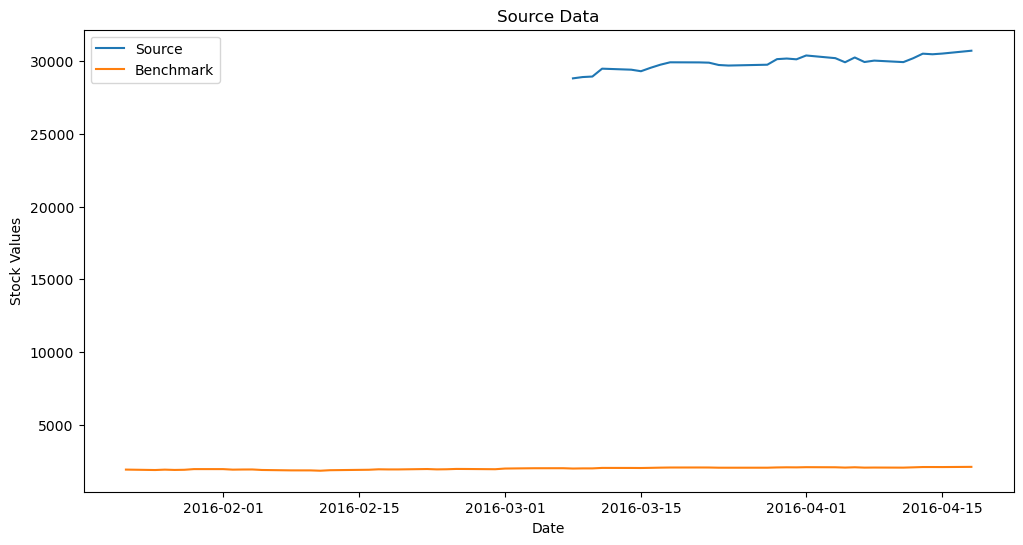

2025-12-09 20:47:03,114 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:03,115 - hrp_logger - INFO - Portfolio return: 0.002572, volatility: 0.008936
2025-12-09 20:47:03,724 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:03,725 - hrp_logger - INFO - Portfolio return: 0.002752, volatility: 0.008721
2025-12-09 20:47:04,332 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:04,333 - hrp_logger - INFO - Portfolio return: 0.002438, volatility: 0.008499
2025-12-09 20:47:04,931 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:04,931 - hrp_logger - INFO - Portfolio return: 0.002659, volatility: 0.008417
2025-12-09 20:47:05,545 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:05,546 - hrp_logger - INFO - Portfolio return: 0.002776, volatility: 0.008398
2025-12-09 20:47:06,170 - hrp_logger - I

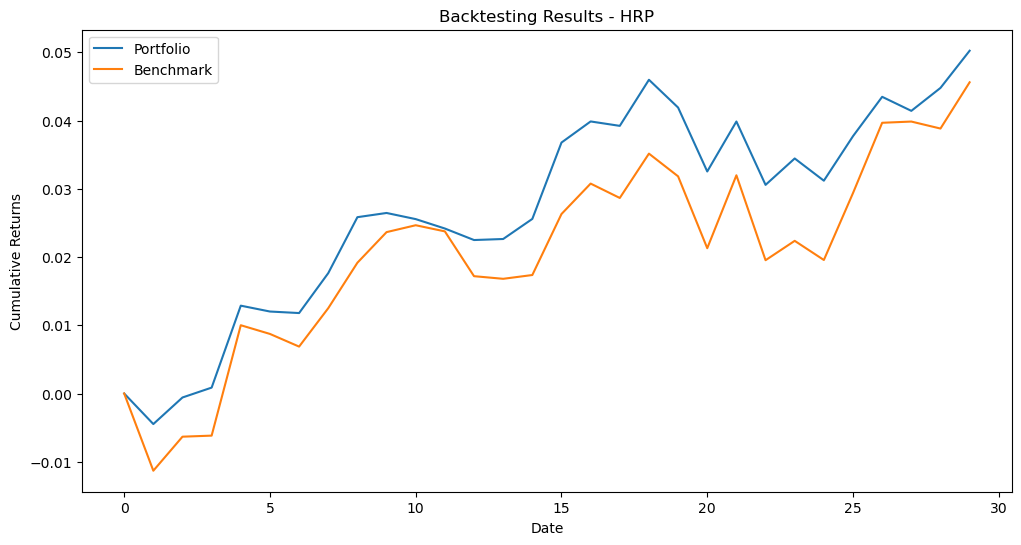

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_0.pkl
initial date: 2021-06-04 00:00:00


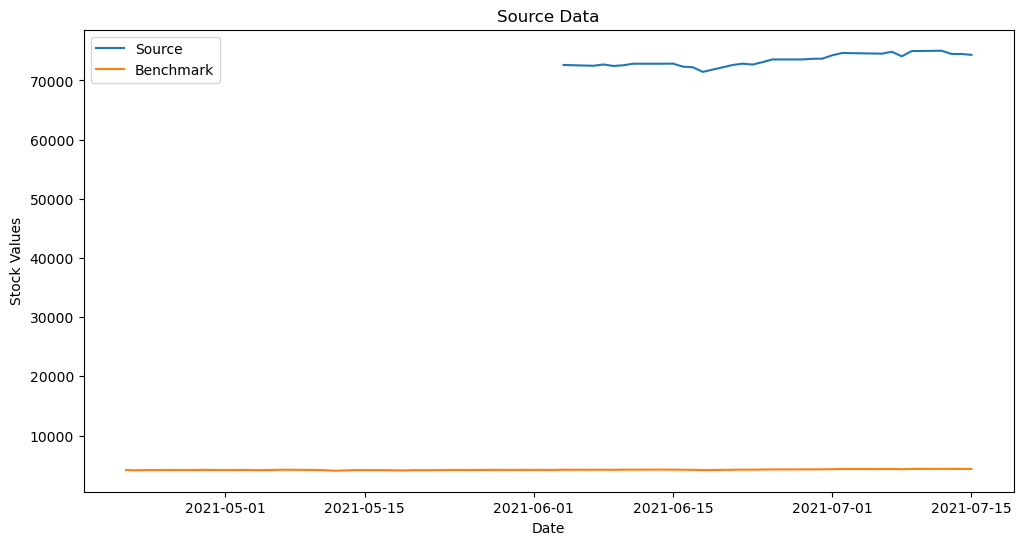

2025-12-09 20:47:20,802 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:20,802 - hrp_logger - INFO - Portfolio return: 0.000465, volatility: 0.006267
2025-12-09 20:47:21,414 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:21,414 - hrp_logger - INFO - Portfolio return: 0.000841, volatility: 0.006180
2025-12-09 20:47:22,014 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:22,014 - hrp_logger - INFO - Portfolio return: 0.000481, volatility: 0.006002
2025-12-09 20:47:22,592 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:22,593 - hrp_logger - INFO - Portfolio return: 0.000682, volatility: 0.006027
2025-12-09 20:47:23,192 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:23,193 - hrp_logger - INFO - Portfolio return: 0.000490, volatility: 0.005927
2025-12-09 20:47:23,841 - hrp_logger - I

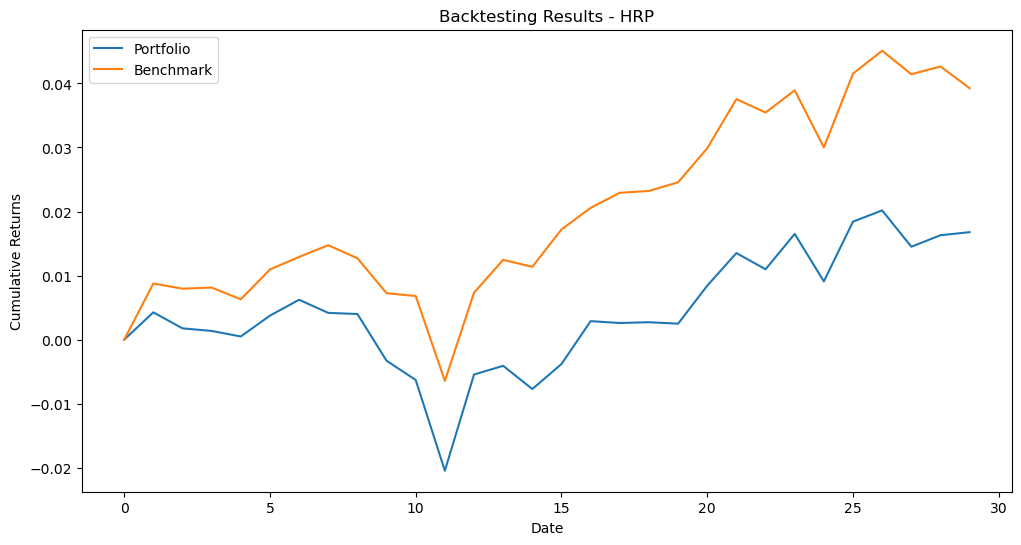

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_1.pkl
initial date: 2024-03-05 00:00:00


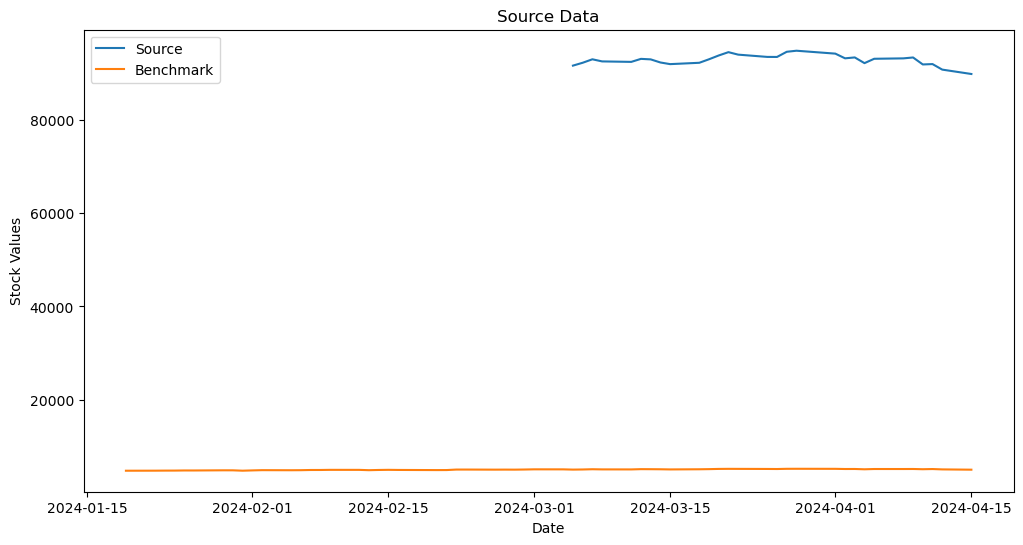

2025-12-09 20:47:38,862 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:38,863 - hrp_logger - INFO - Portfolio return: 0.001566, volatility: 0.003823
2025-12-09 20:47:39,448 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:39,449 - hrp_logger - INFO - Portfolio return: 0.001398, volatility: 0.004373
2025-12-09 20:47:40,055 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:40,056 - hrp_logger - INFO - Portfolio return: 0.001397, volatility: 0.004362
2025-12-09 20:47:40,651 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:40,652 - hrp_logger - INFO - Portfolio return: 0.001483, volatility: 0.004221
2025-12-09 20:47:41,270 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:41,270 - hrp_logger - INFO - Portfolio return: 0.001357, volatility: 0.003879
2025-12-09 20:47:41,861 - hrp_logger - I

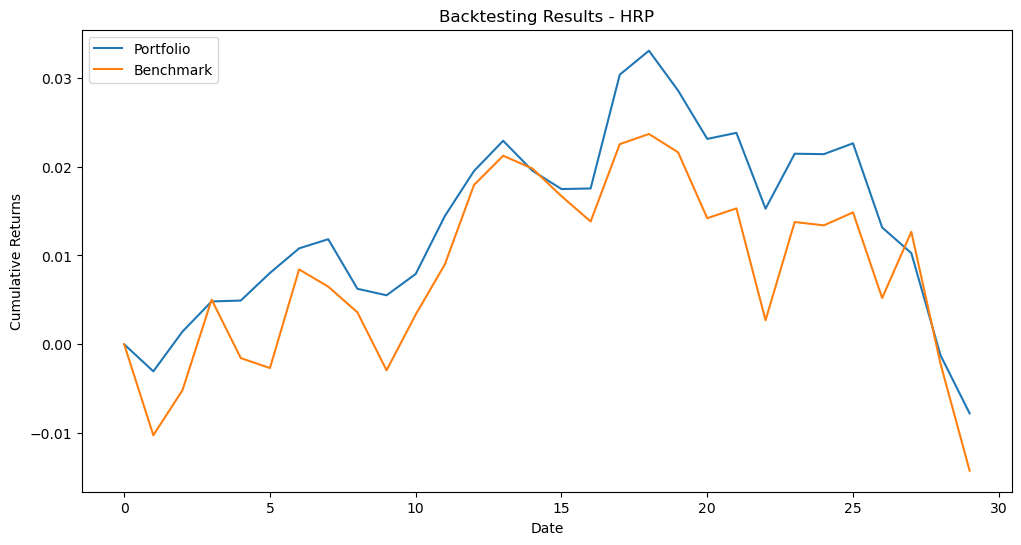

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_2.pkl
initial date: 2020-06-25 00:00:00


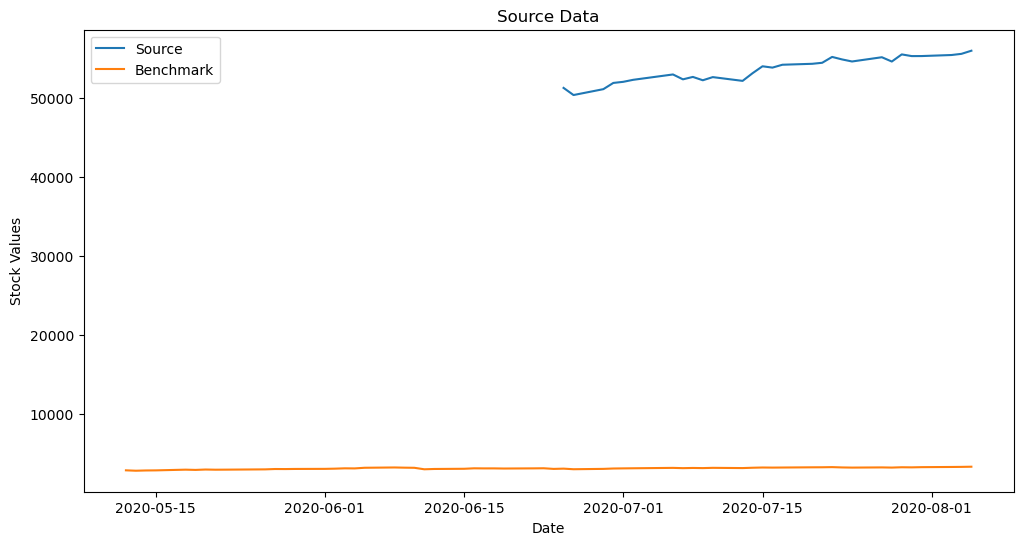

2025-12-09 20:47:56,790 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:56,791 - hrp_logger - INFO - Portfolio return: 0.001313, volatility: 0.012932
2025-12-09 20:47:57,401 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:57,402 - hrp_logger - INFO - Portfolio return: 0.002098, volatility: 0.012949
2025-12-09 20:47:58,044 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:58,045 - hrp_logger - INFO - Portfolio return: 0.001392, volatility: 0.013301
2025-12-09 20:47:58,671 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:58,672 - hrp_logger - INFO - Portfolio return: 0.001623, volatility: 0.013488
2025-12-09 20:47:59,287 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:47:59,288 - hrp_logger - INFO - Portfolio return: 0.001303, volatility: 0.012846
2025-12-09 20:47:59,895 - hrp_logger - I

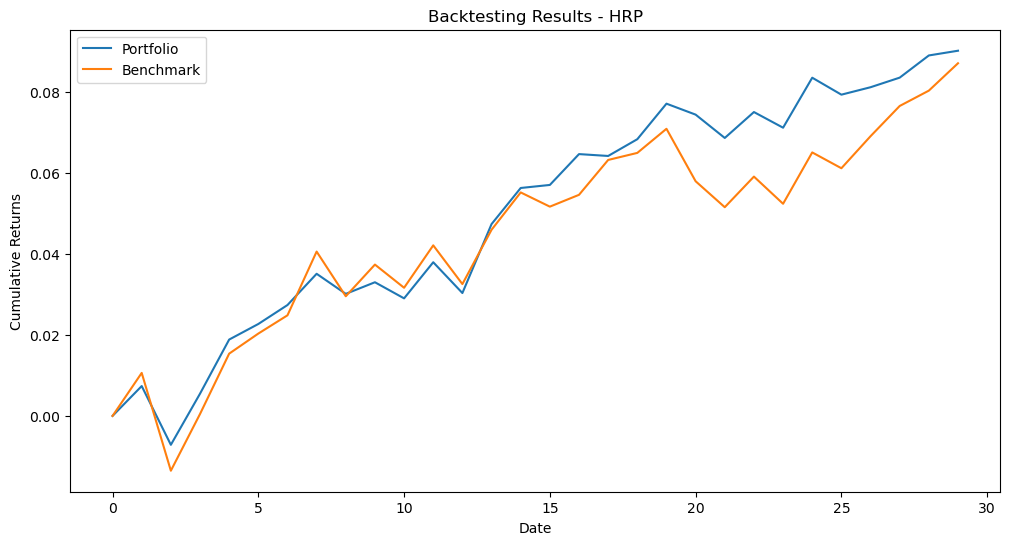

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_3.pkl
initial date: 2024-06-07 00:00:00


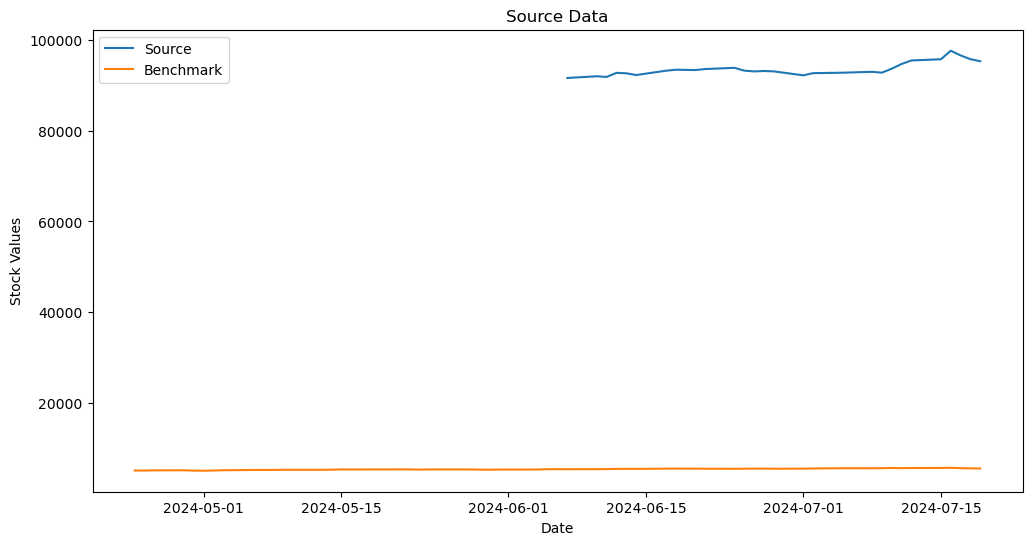

2025-12-09 20:48:14,657 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:14,658 - hrp_logger - INFO - Portfolio return: 0.000465, volatility: 0.005606
2025-12-09 20:48:15,220 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:15,221 - hrp_logger - INFO - Portfolio return: 0.000427, volatility: 0.005679
2025-12-09 20:48:15,783 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:15,783 - hrp_logger - INFO - Portfolio return: 0.000534, volatility: 0.005630
2025-12-09 20:48:16,312 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:16,313 - hrp_logger - INFO - Portfolio return: 0.000332, volatility: 0.005399
2025-12-09 20:48:16,819 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:16,819 - hrp_logger - INFO - Portfolio return: 0.000685, volatility: 0.005219
2025-12-09 20:48:17,454 - hrp_logger - I

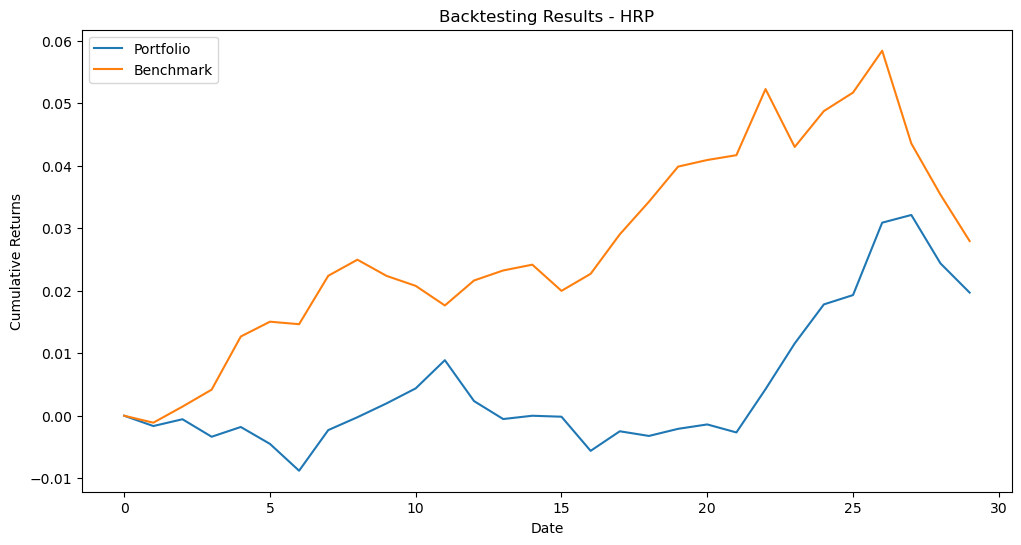

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_4.pkl
initial date: 2014-02-07 00:00:00


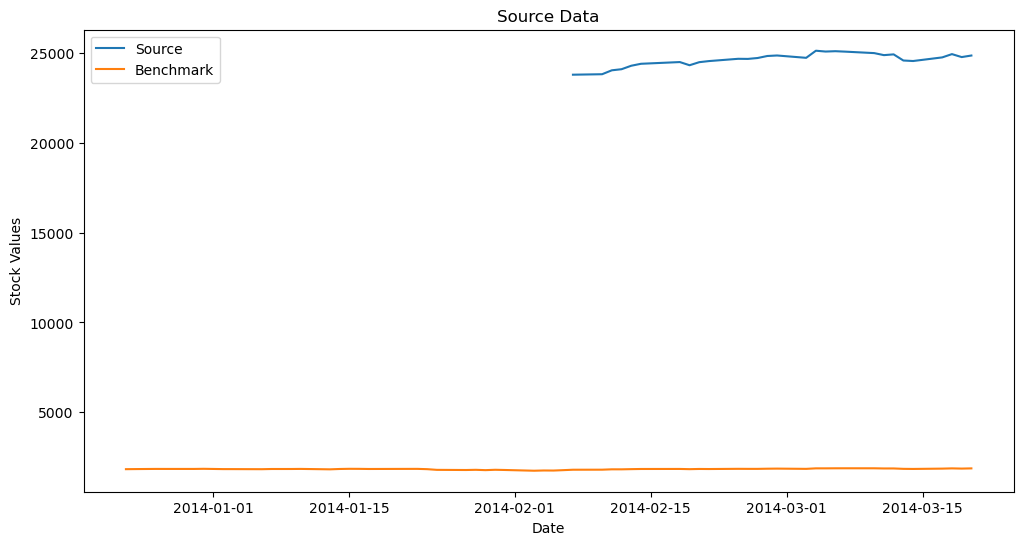

2025-12-09 20:48:32,971 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:32,971 - hrp_logger - INFO - Portfolio return: -0.000346, volatility: 0.007460
2025-12-09 20:48:33,589 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:33,590 - hrp_logger - INFO - Portfolio return: -0.000183, volatility: 0.007756
2025-12-09 20:48:34,227 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:34,228 - hrp_logger - INFO - Portfolio return: -0.000233, volatility: 0.007622
2025-12-09 20:48:34,816 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:34,816 - hrp_logger - INFO - Portfolio return: 0.000226, volatility: 0.007852
2025-12-09 20:48:35,436 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:35,437 - hrp_logger - INFO - Portfolio return: 0.000058, volatility: 0.007861
2025-12-09 20:48:36,085 - hrp_logger 

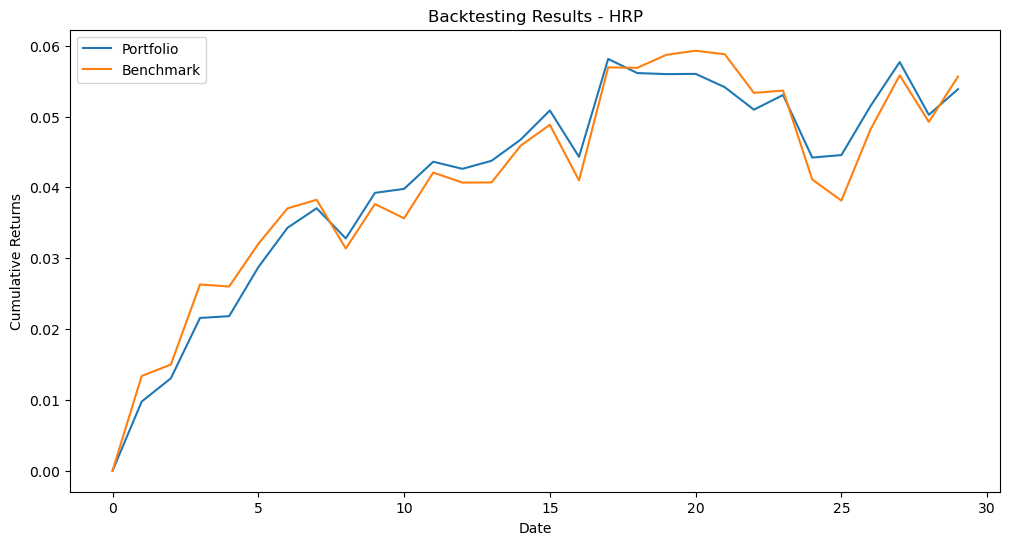

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_5.pkl
initial date: 2016-04-21 00:00:00


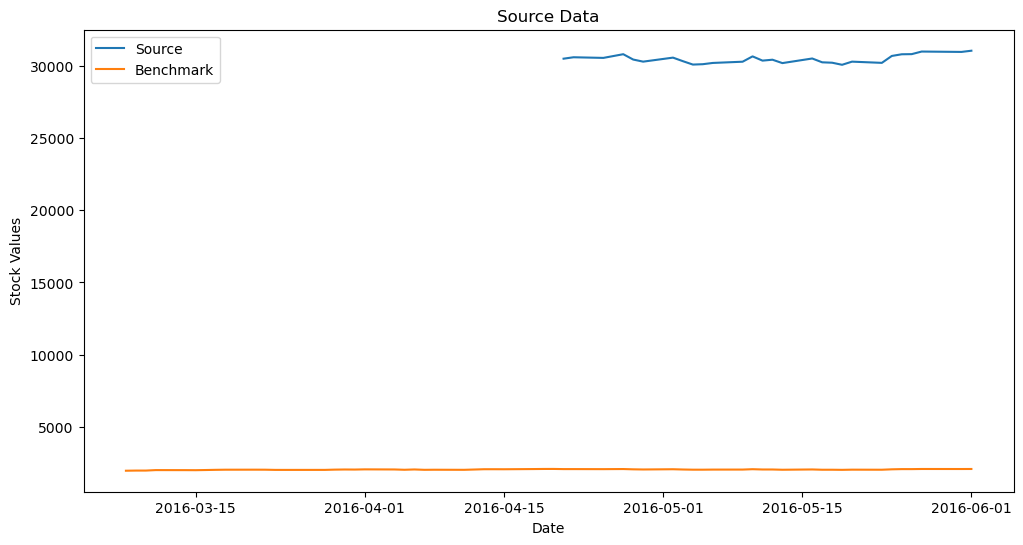

2025-12-09 20:48:51,095 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:51,096 - hrp_logger - INFO - Portfolio return: 0.001800, volatility: 0.005146
2025-12-09 20:48:51,661 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:51,661 - hrp_logger - INFO - Portfolio return: 0.001555, volatility: 0.005582
2025-12-09 20:48:52,255 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:52,255 - hrp_logger - INFO - Portfolio return: 0.001579, volatility: 0.005460
2025-12-09 20:48:52,822 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:52,822 - hrp_logger - INFO - Portfolio return: 0.001218, volatility: 0.005186
2025-12-09 20:48:53,407 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:48:53,408 - hrp_logger - INFO - Portfolio return: 0.001303, volatility: 0.005207
2025-12-09 20:48:53,924 - hrp_logger - I

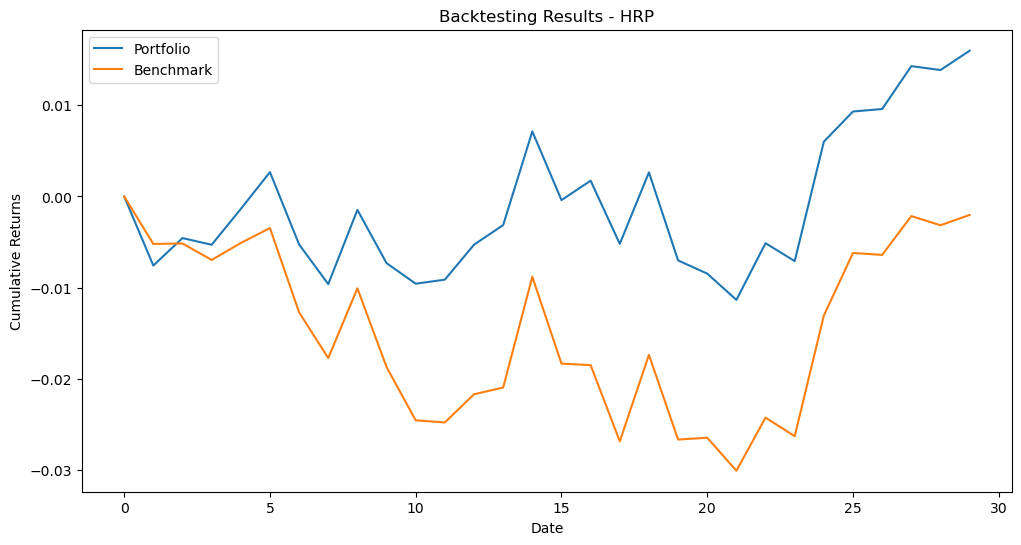

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_6.pkl
initial date: 2020-05-11 00:00:00


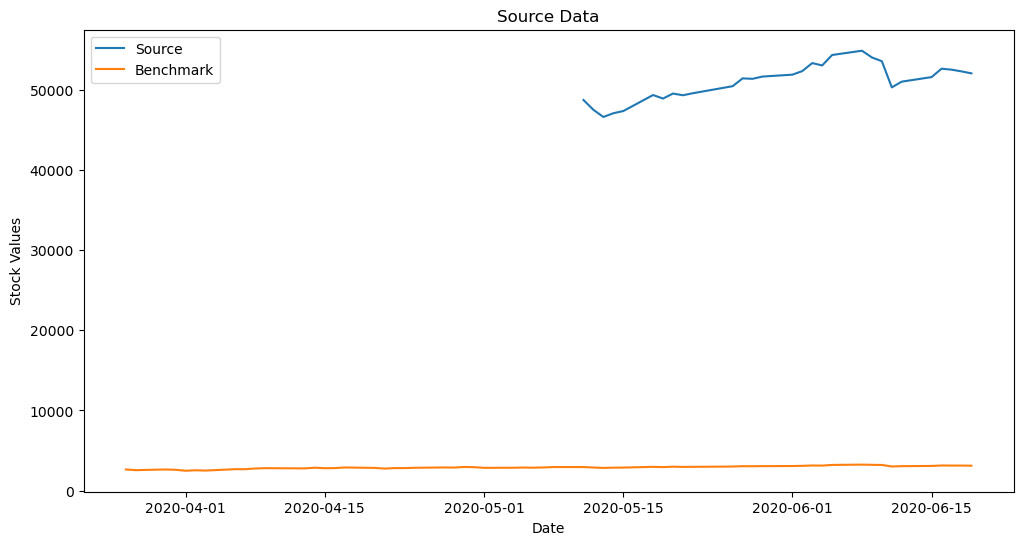

2025-12-09 20:49:09,107 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:09,107 - hrp_logger - INFO - Portfolio return: 0.003822, volatility: 0.020130
2025-12-09 20:49:09,724 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:09,725 - hrp_logger - INFO - Portfolio return: 0.004488, volatility: 0.019698
2025-12-09 20:49:10,325 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:10,325 - hrp_logger - INFO - Portfolio return: 0.002968, volatility: 0.018466
2025-12-09 20:49:10,970 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:10,971 - hrp_logger - INFO - Portfolio return: 0.003006, volatility: 0.018285
2025-12-09 20:49:11,557 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:11,557 - hrp_logger - INFO - Portfolio return: 0.004291, volatility: 0.017841
2025-12-09 20:49:12,189 - hrp_logger - I

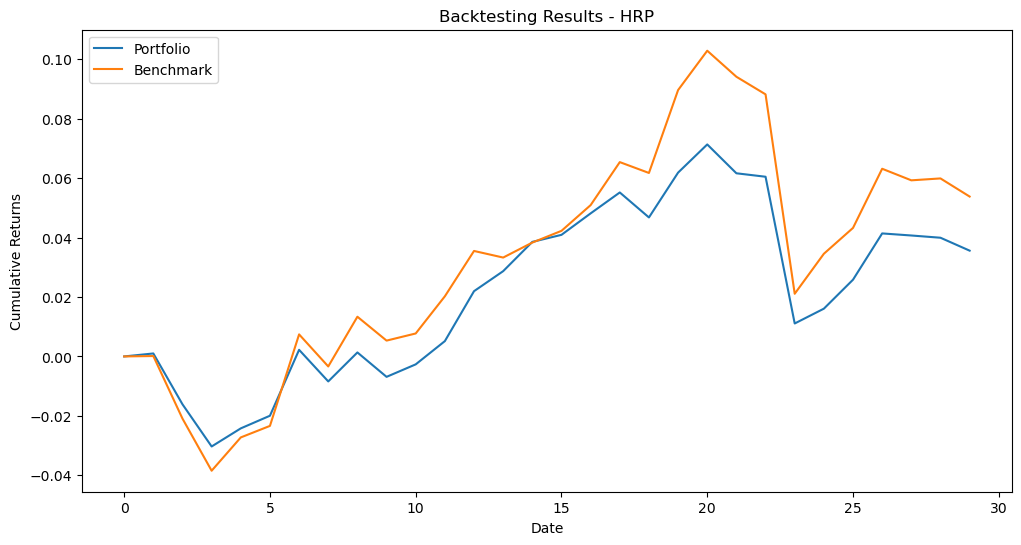

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_7.pkl
initial date: 2016-11-30 00:00:00


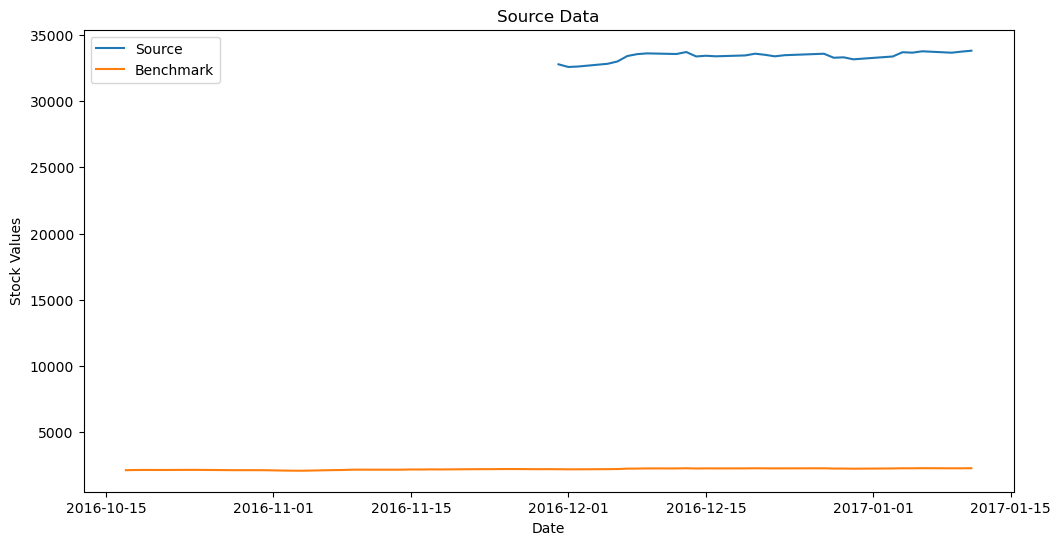

2025-12-09 20:49:27,150 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:27,151 - hrp_logger - INFO - Portfolio return: 0.001646, volatility: 0.004822
2025-12-09 20:49:27,750 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:27,750 - hrp_logger - INFO - Portfolio return: 0.001274, volatility: 0.005180
2025-12-09 20:49:28,333 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:28,333 - hrp_logger - INFO - Portfolio return: 0.001199, volatility: 0.005156
2025-12-09 20:49:28,931 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:28,932 - hrp_logger - INFO - Portfolio return: 0.001258, volatility: 0.005137
2025-12-09 20:49:29,484 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:29,484 - hrp_logger - INFO - Portfolio return: 0.001615, volatility: 0.004960
2025-12-09 20:49:30,076 - hrp_logger - I

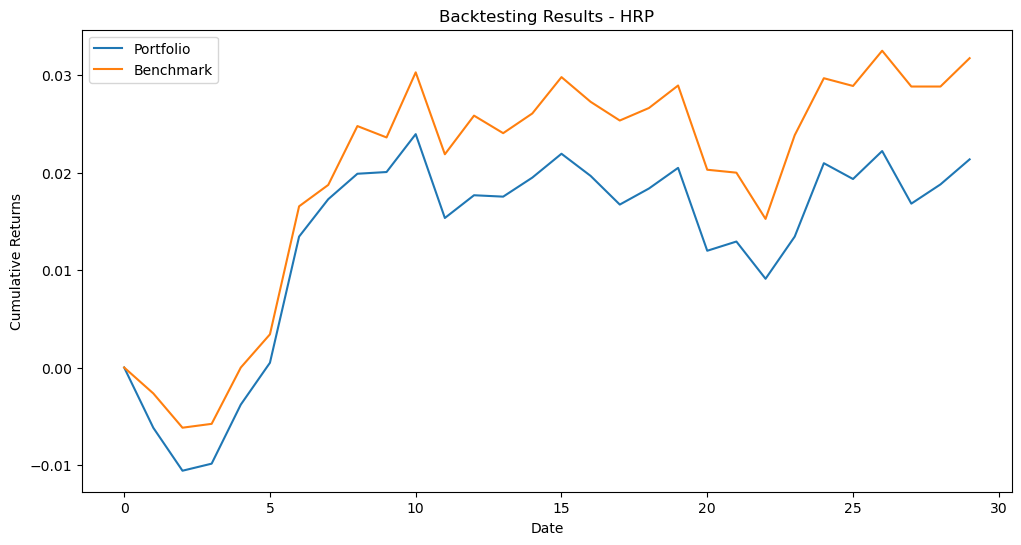

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_8.pkl
initial date: 2021-08-25 00:00:00


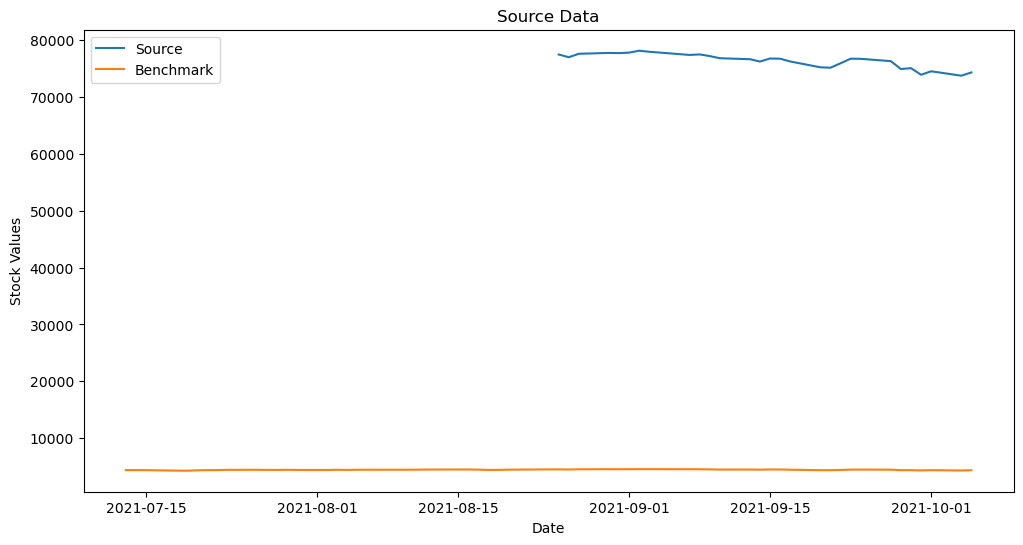

2025-12-09 20:49:44,768 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:44,769 - hrp_logger - INFO - Portfolio return: 0.001121, volatility: 0.004850
2025-12-09 20:49:45,354 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:45,354 - hrp_logger - INFO - Portfolio return: 0.001078, volatility: 0.005000
2025-12-09 20:49:45,926 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:45,927 - hrp_logger - INFO - Portfolio return: 0.000989, volatility: 0.005131
2025-12-09 20:49:46,560 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:46,560 - hrp_logger - INFO - Portfolio return: 0.001182, volatility: 0.004955
2025-12-09 20:49:47,154 - hrp_logger - INFO - Riskfolio HRP optimization completed successfully.
2025-12-09 20:49:47,155 - hrp_logger - INFO - Portfolio return: 0.001673, volatility: 0.004493
2025-12-09 20:49:47,779 - hrp_logger - I

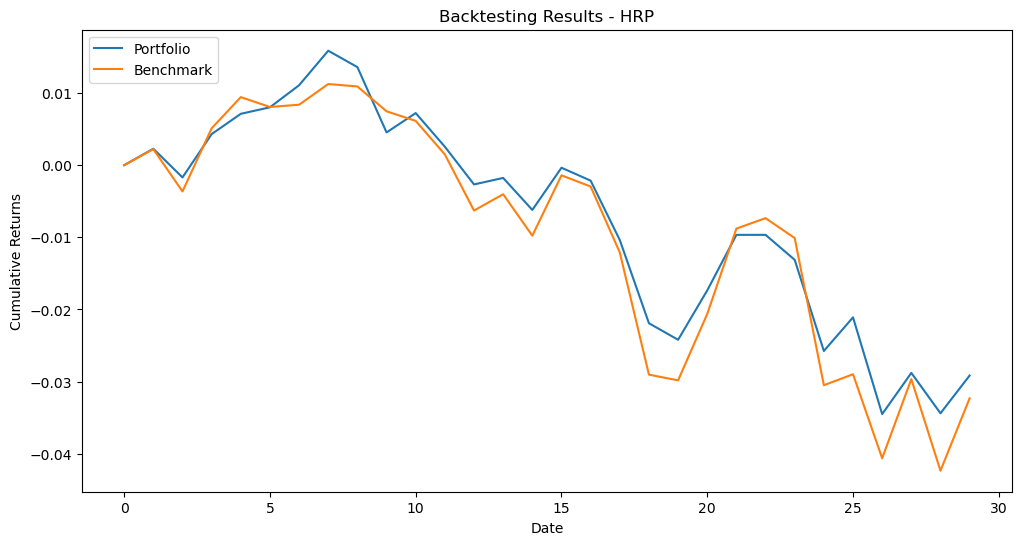

Dictionary pickled and saved to ../../results/hrp/results_hrp_pearson_ward_9.pkl


In [12]:
# HRP with default parameters
opt_fun_hrp = partial(riskfolio_hrp, codependence='pearson', linkage='ward')
results_path_hrp = '../../results/hrp/results_hrp_pearson_ward_{}.pkl'
_ = run_experiment(results_path_hrp, source, benchmark, opt_fun_hrp, parameters)

### Experiment 2: Equal Weights Baseline

initial date: 2016-03-08 00:00:00


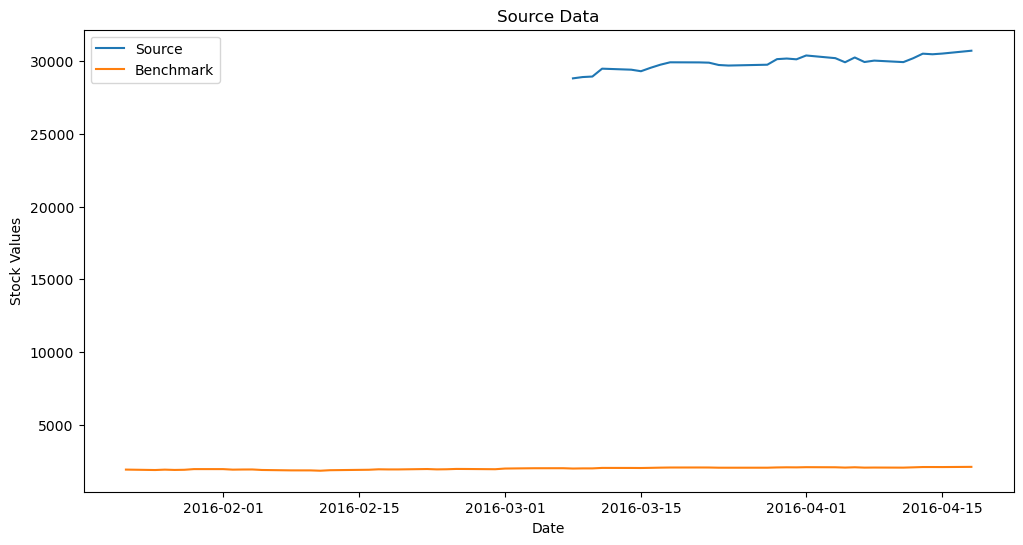

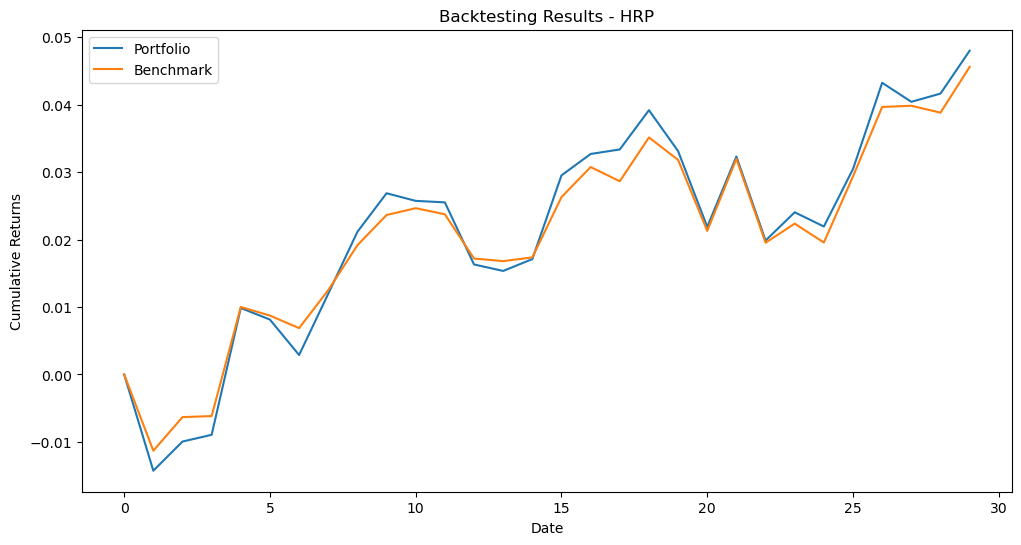

Dictionary pickled and saved to ../../results/hrp/results_ew_0.pkl
initial date: 2021-06-04 00:00:00


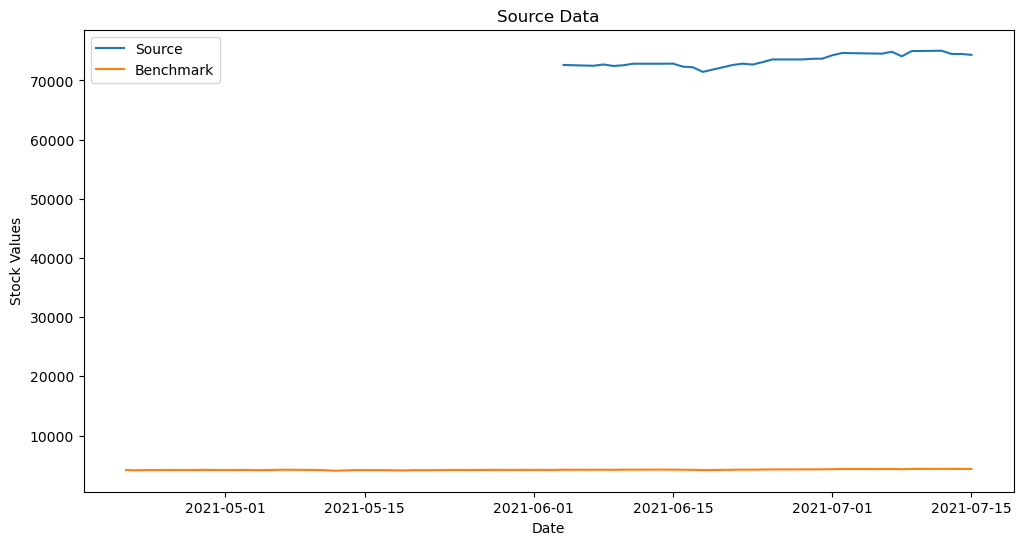

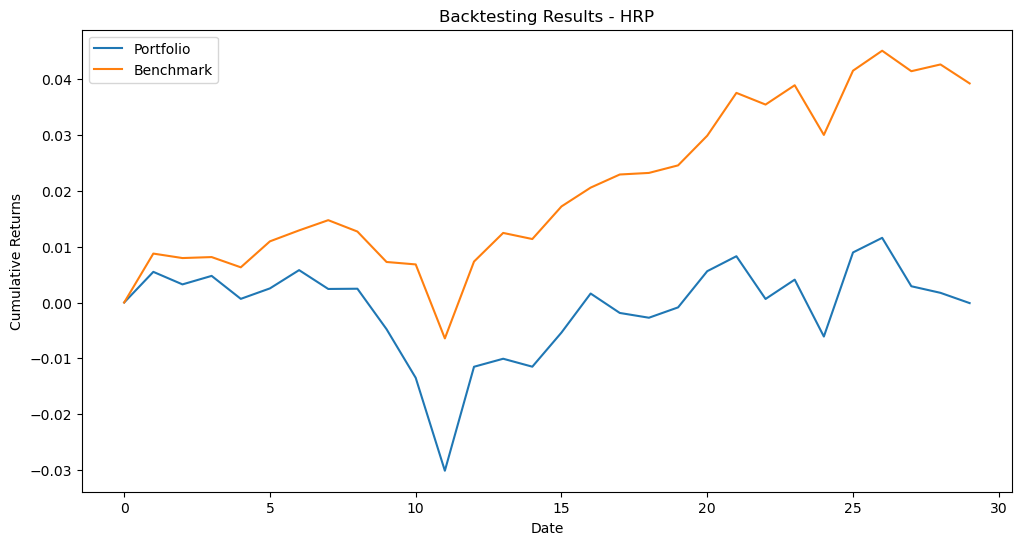

Dictionary pickled and saved to ../../results/hrp/results_ew_1.pkl
initial date: 2024-03-05 00:00:00


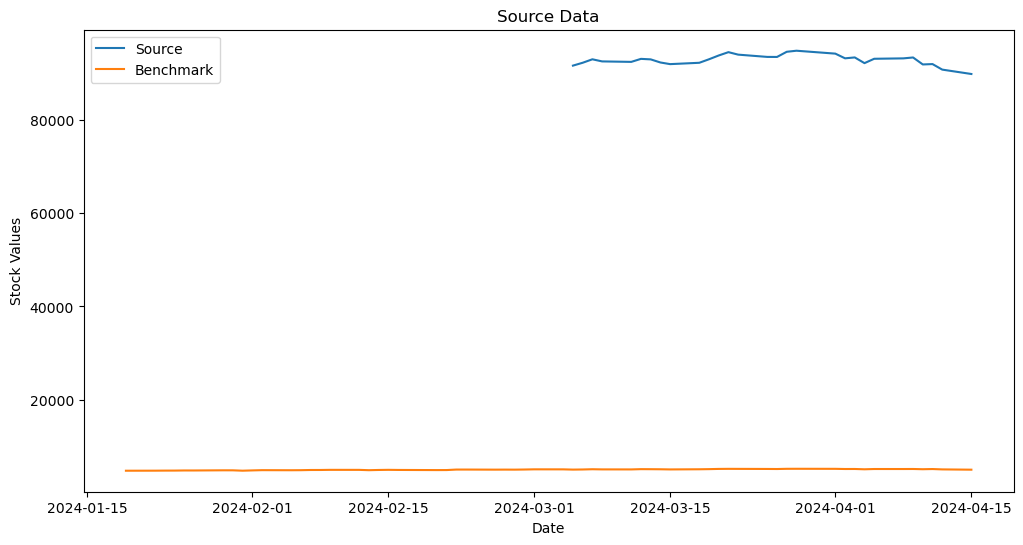

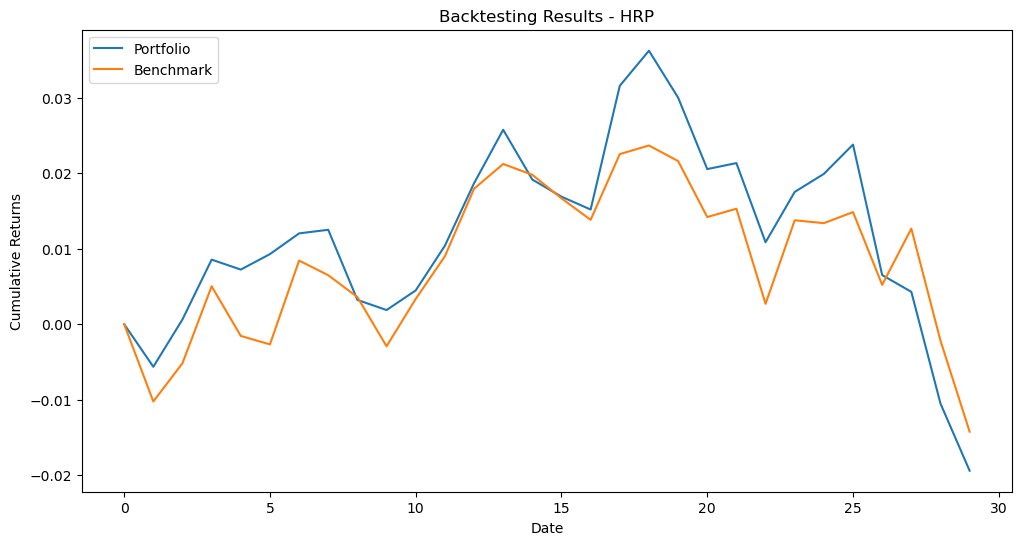

Dictionary pickled and saved to ../../results/hrp/results_ew_2.pkl
initial date: 2020-06-25 00:00:00


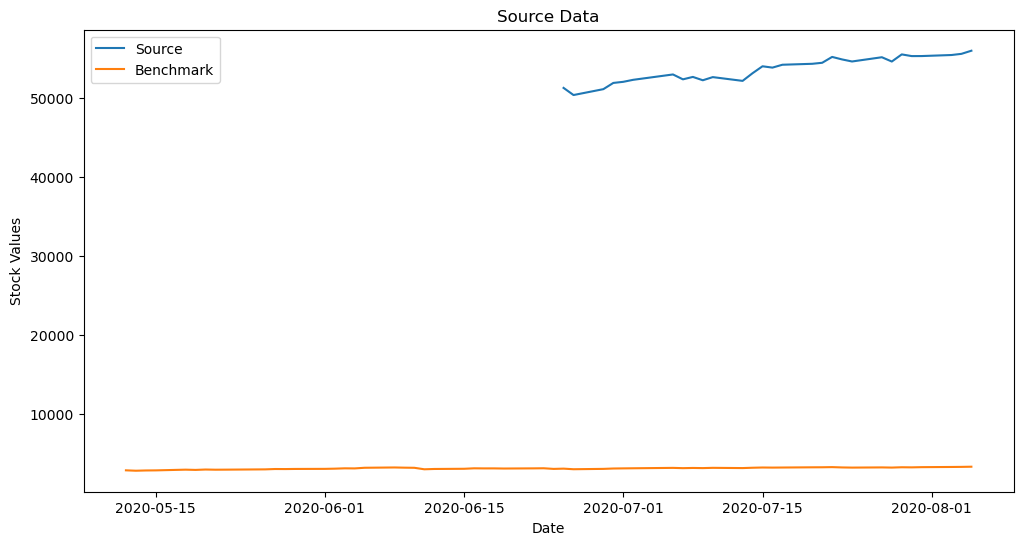

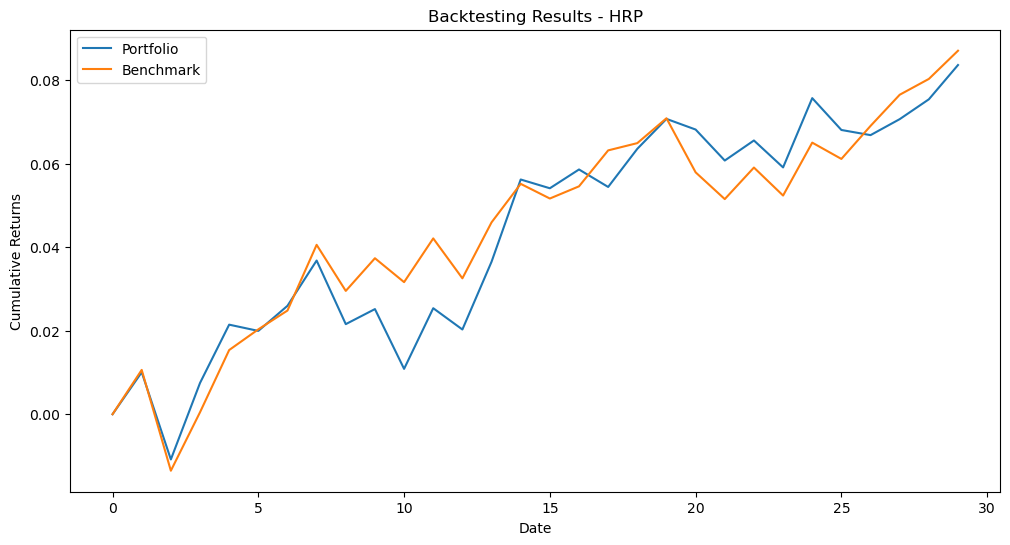

Dictionary pickled and saved to ../../results/hrp/results_ew_3.pkl
initial date: 2024-06-07 00:00:00


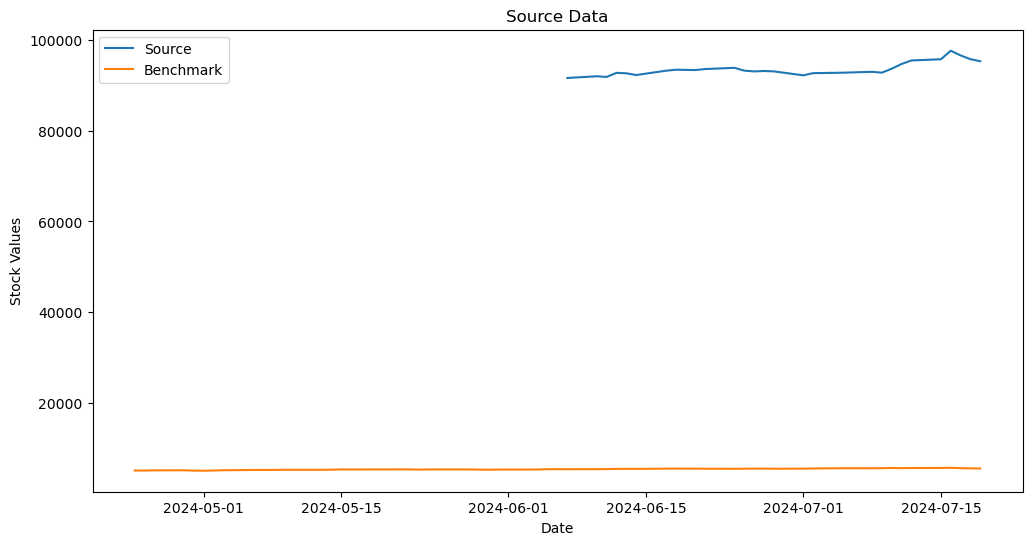

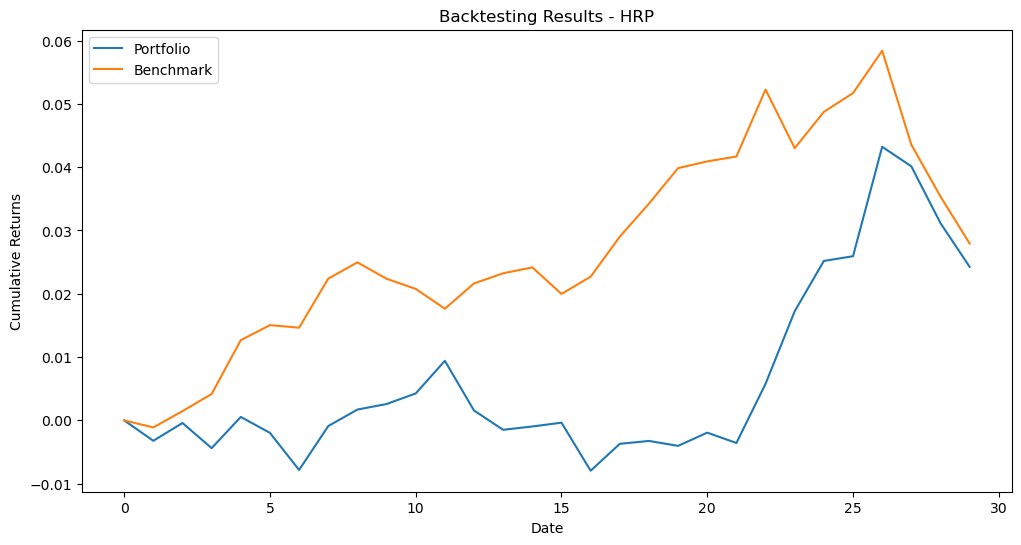

Dictionary pickled and saved to ../../results/hrp/results_ew_4.pkl
initial date: 2014-02-07 00:00:00


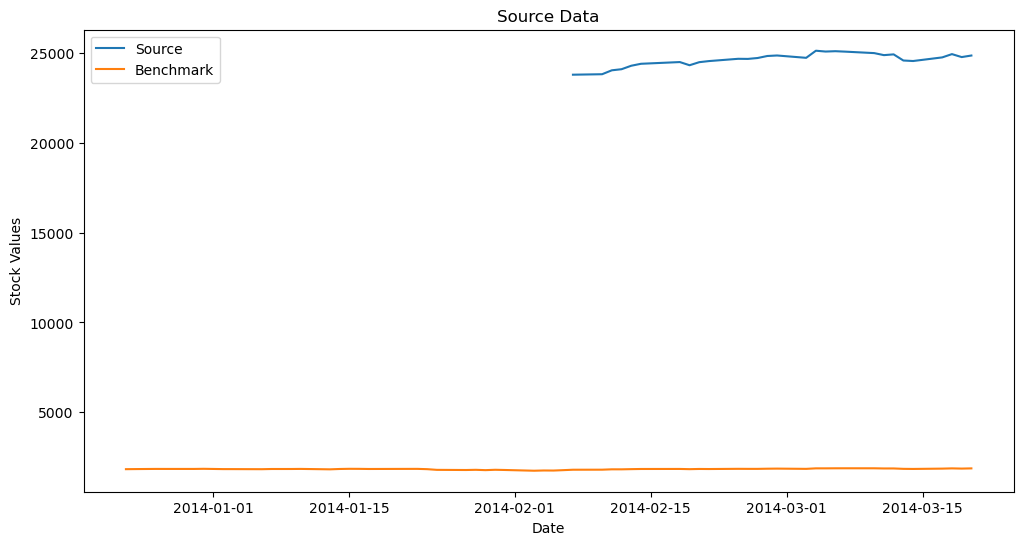

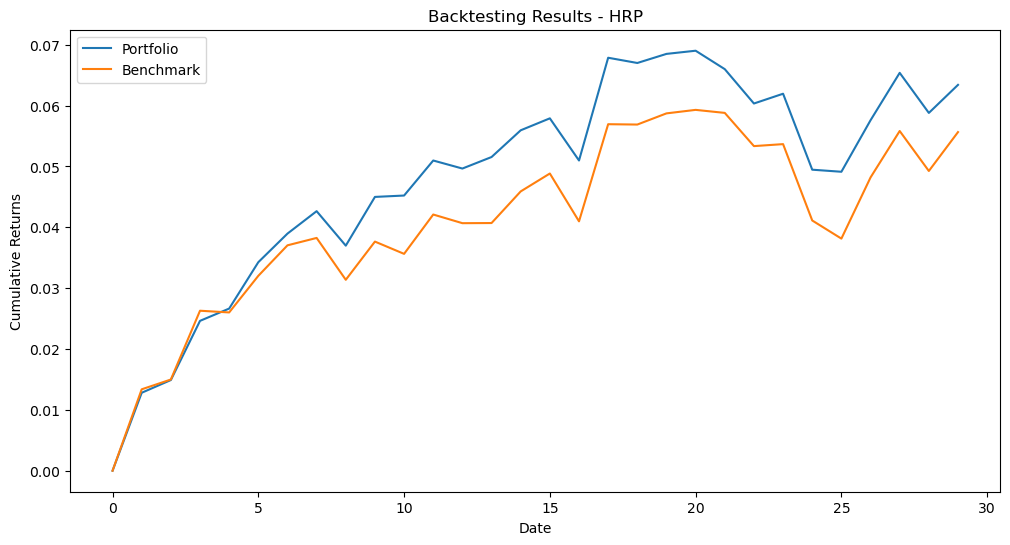

Dictionary pickled and saved to ../../results/hrp/results_ew_5.pkl
initial date: 2016-04-21 00:00:00


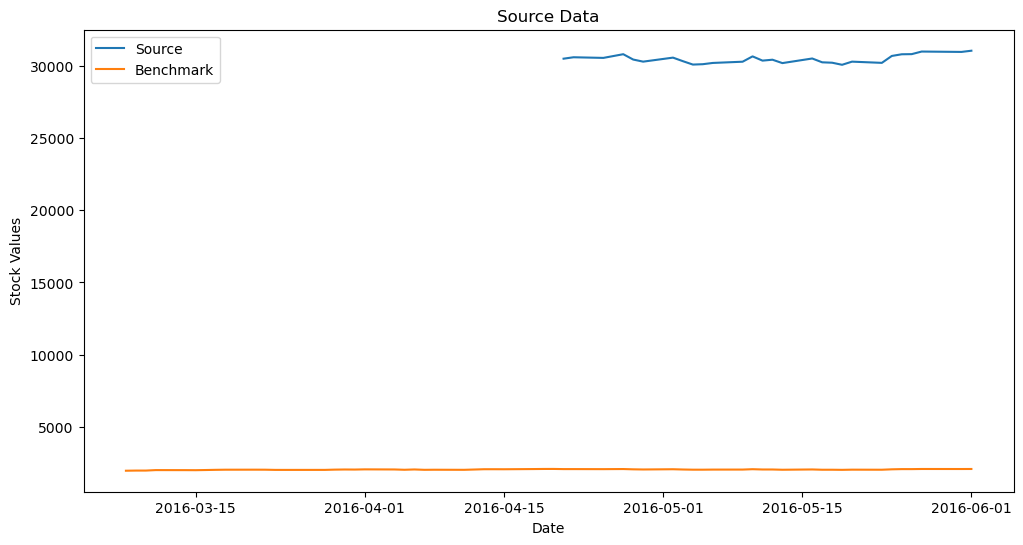

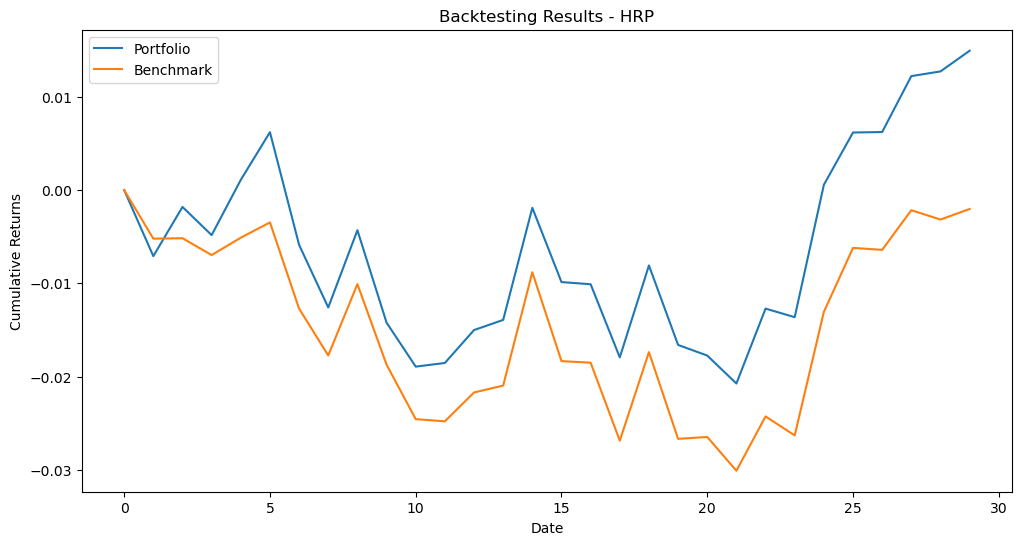

Dictionary pickled and saved to ../../results/hrp/results_ew_6.pkl
initial date: 2020-05-11 00:00:00


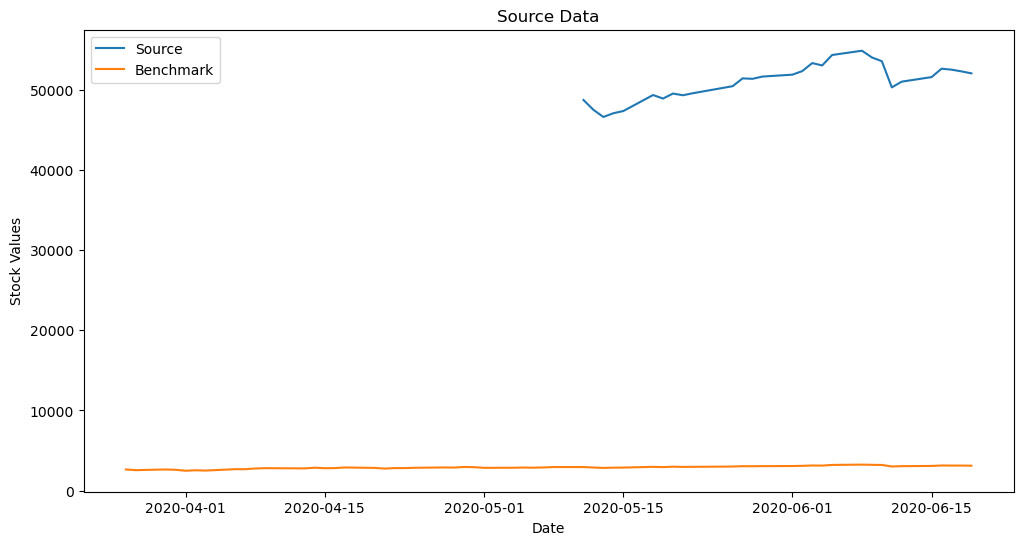

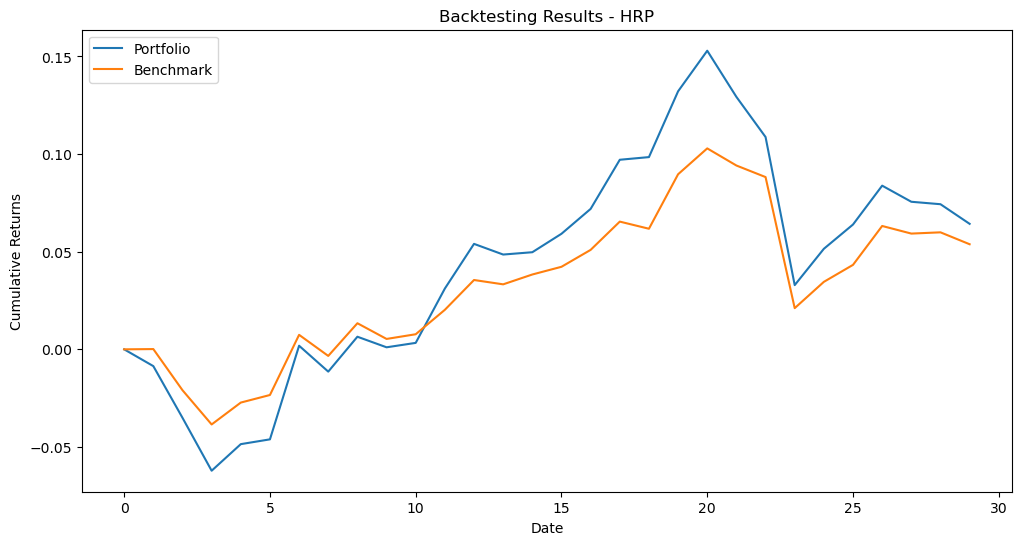

Dictionary pickled and saved to ../../results/hrp/results_ew_7.pkl
initial date: 2016-11-30 00:00:00


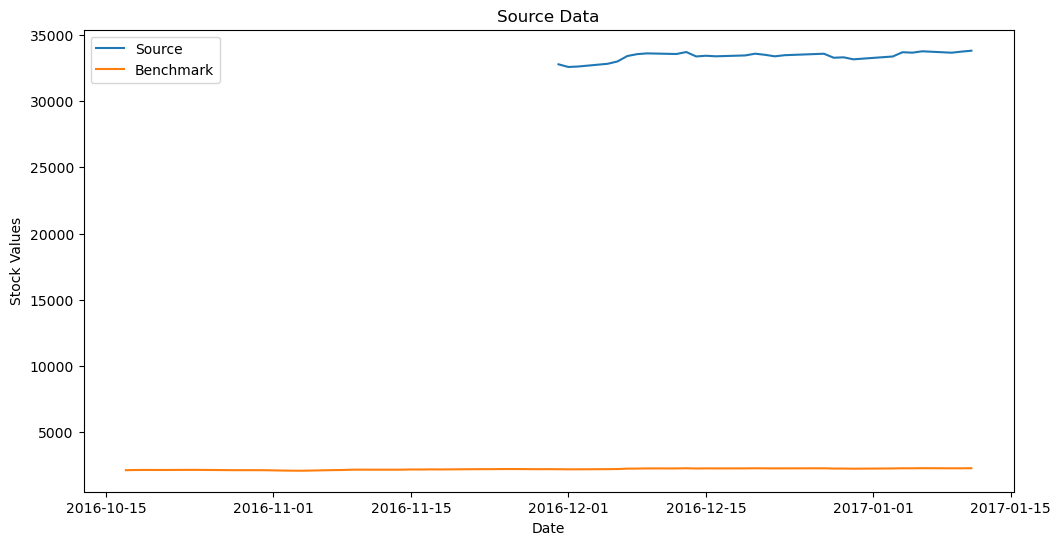

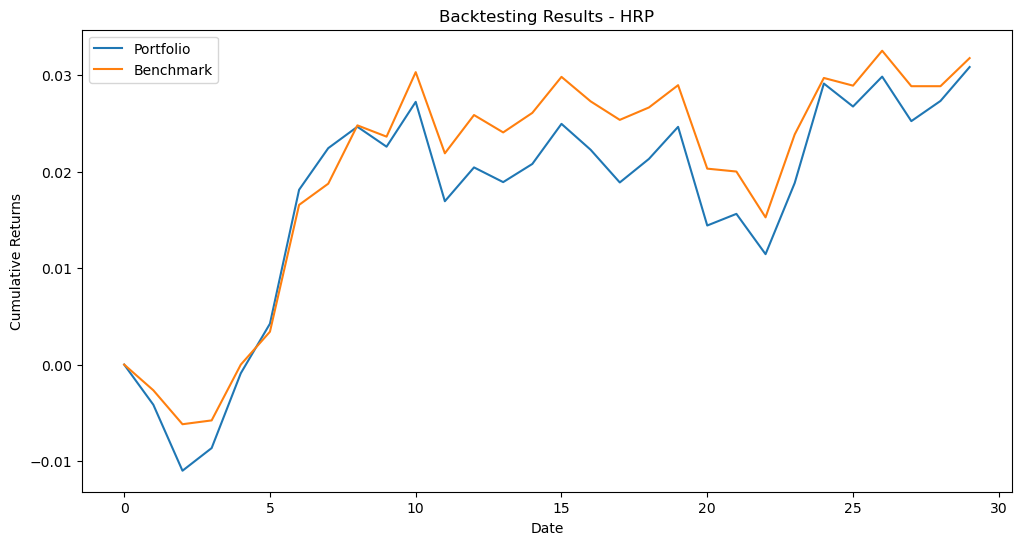

Dictionary pickled and saved to ../../results/hrp/results_ew_8.pkl
initial date: 2021-08-25 00:00:00


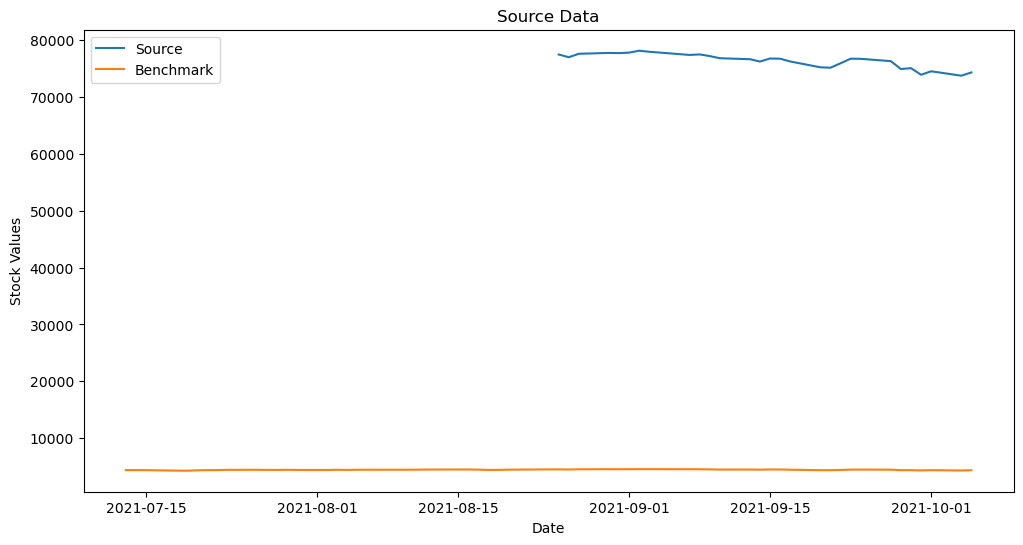

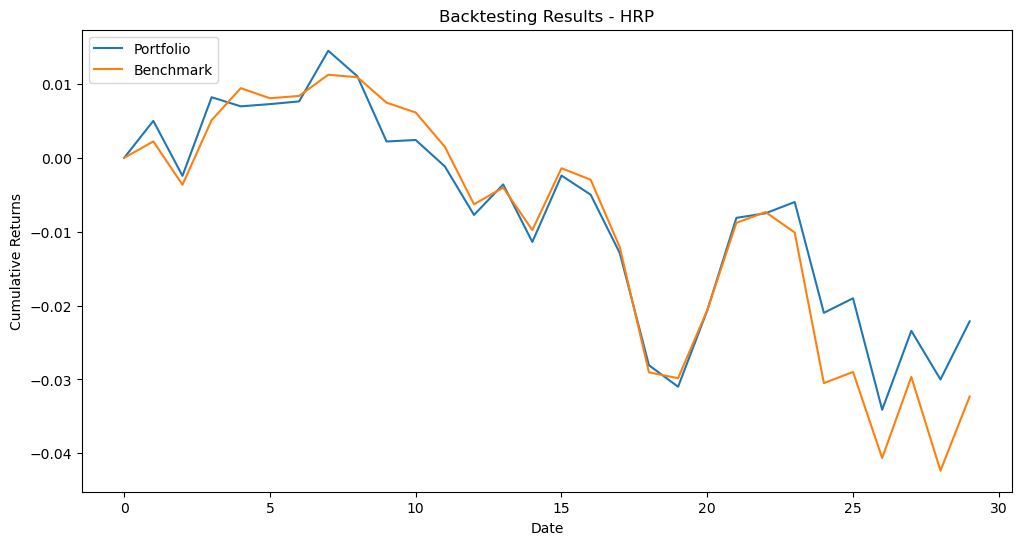

Dictionary pickled and saved to ../../results/hrp/results_ew_9.pkl


In [13]:
# Equal weights baseline for comparison
opt_fun_ew = partial(equal_weights_baseline)
results_path_ew = '../../results/hrp/results_ew_{}.pkl'
_ = run_experiment(results_path_ew, source, benchmark, opt_fun_ew, parameters)

### HRP Variants Comparison

2025-12-09 20:50:04,146 - hrp_logger - INFO - Period 0: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,147 - hrp_logger - INFO - Period 0: Loaded HRP (Pearson + Ward) (exec_time: 17.63s)


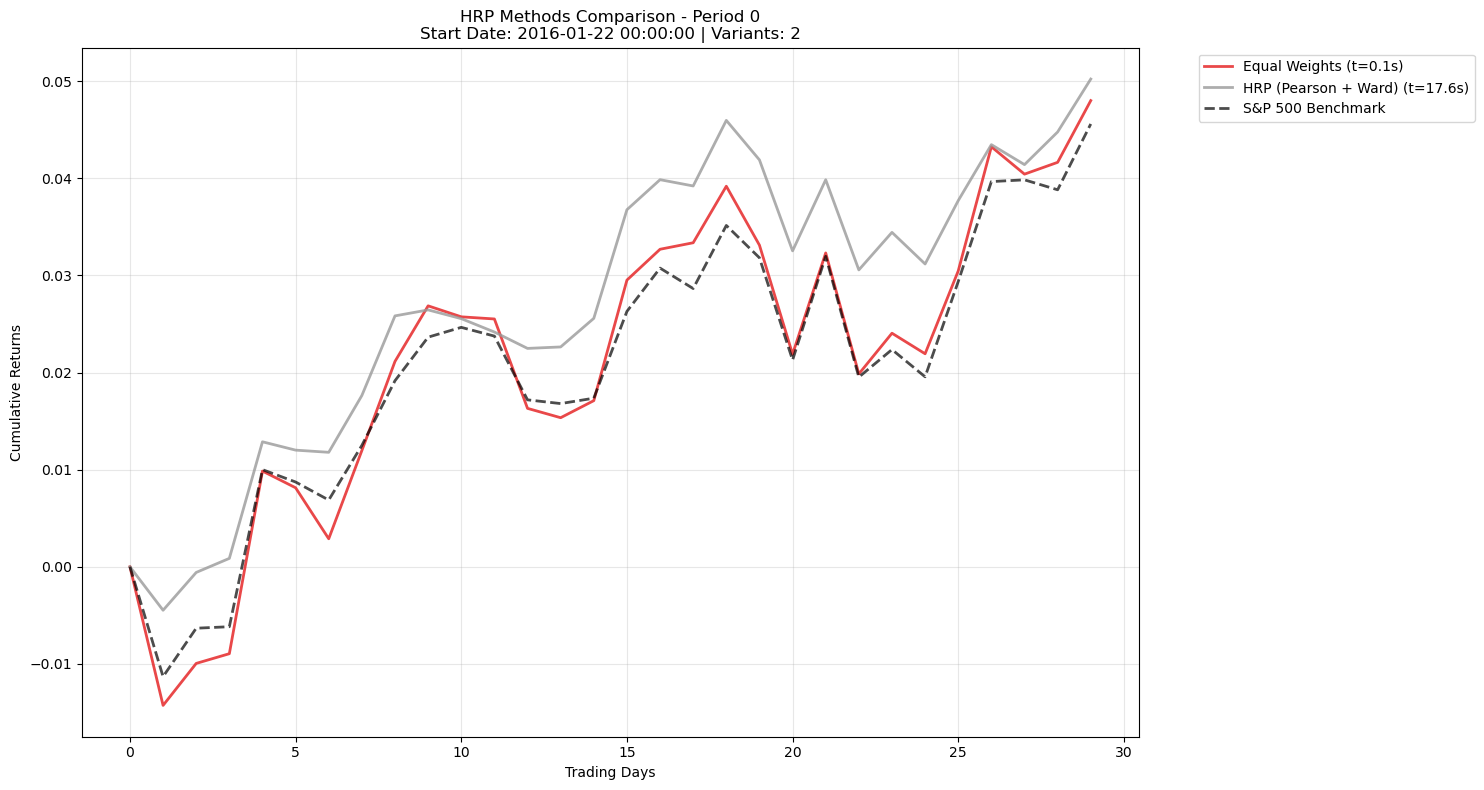

2025-12-09 20:50:04,243 - hrp_logger - INFO - Period 1: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,245 - hrp_logger - INFO - Period 1: Loaded HRP (Pearson + Ward) (exec_time: 18.00s)



Period 0 Summary:
--------------------------------------------------
Equal Weights            :   0.0480 (  0.09s)
HRP (Pearson + Ward)     :   0.0502 ( 17.63s)
Benchmark                :   0.0456



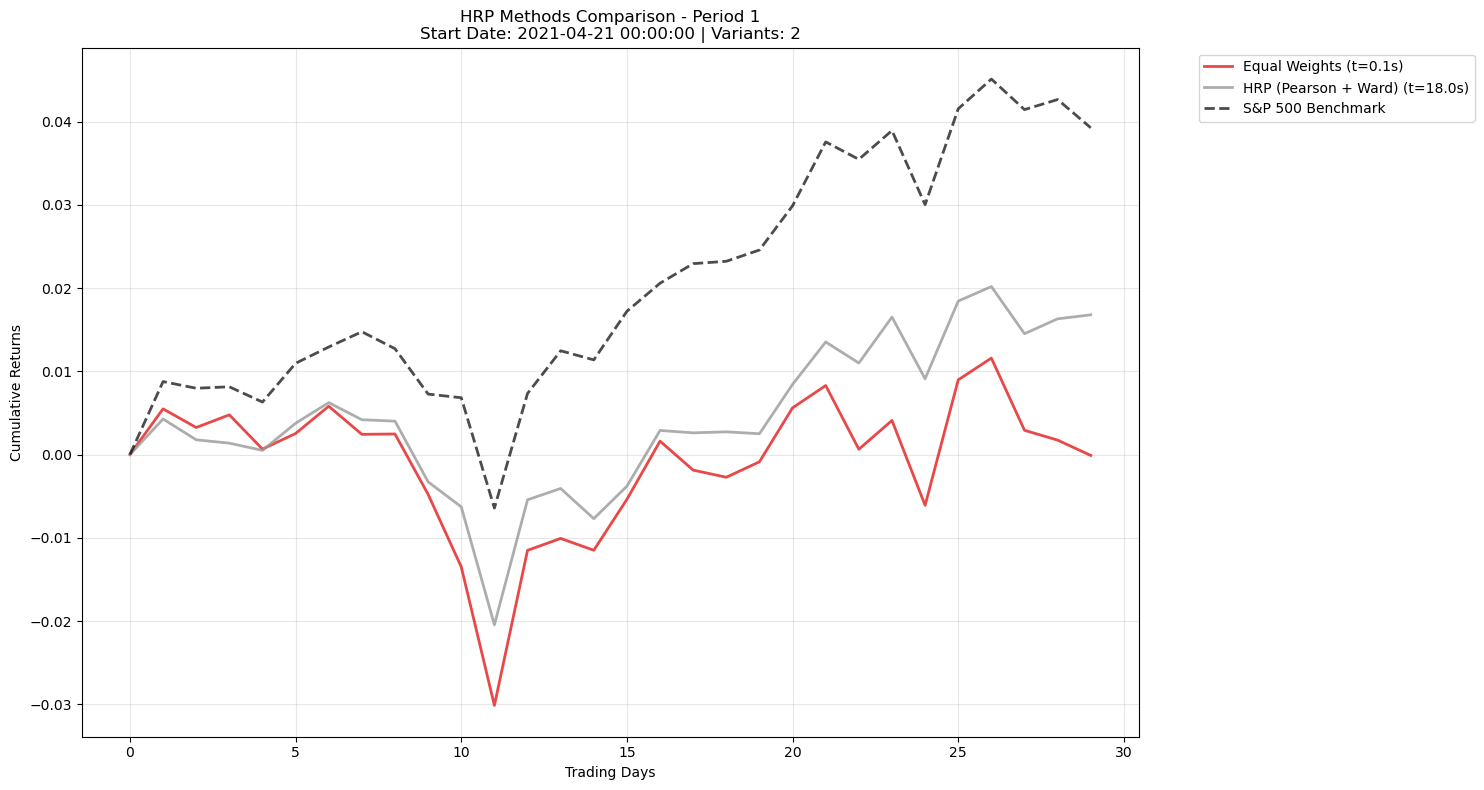

2025-12-09 20:50:04,343 - hrp_logger - INFO - Period 2: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,344 - hrp_logger - INFO - Period 2: Loaded HRP (Pearson + Ward) (exec_time: 17.88s)



Period 1 Summary:
--------------------------------------------------
Equal Weights            :  -0.0001 (  0.09s)
HRP (Pearson + Ward)     :   0.0168 ( 18.00s)
Benchmark                :   0.0392



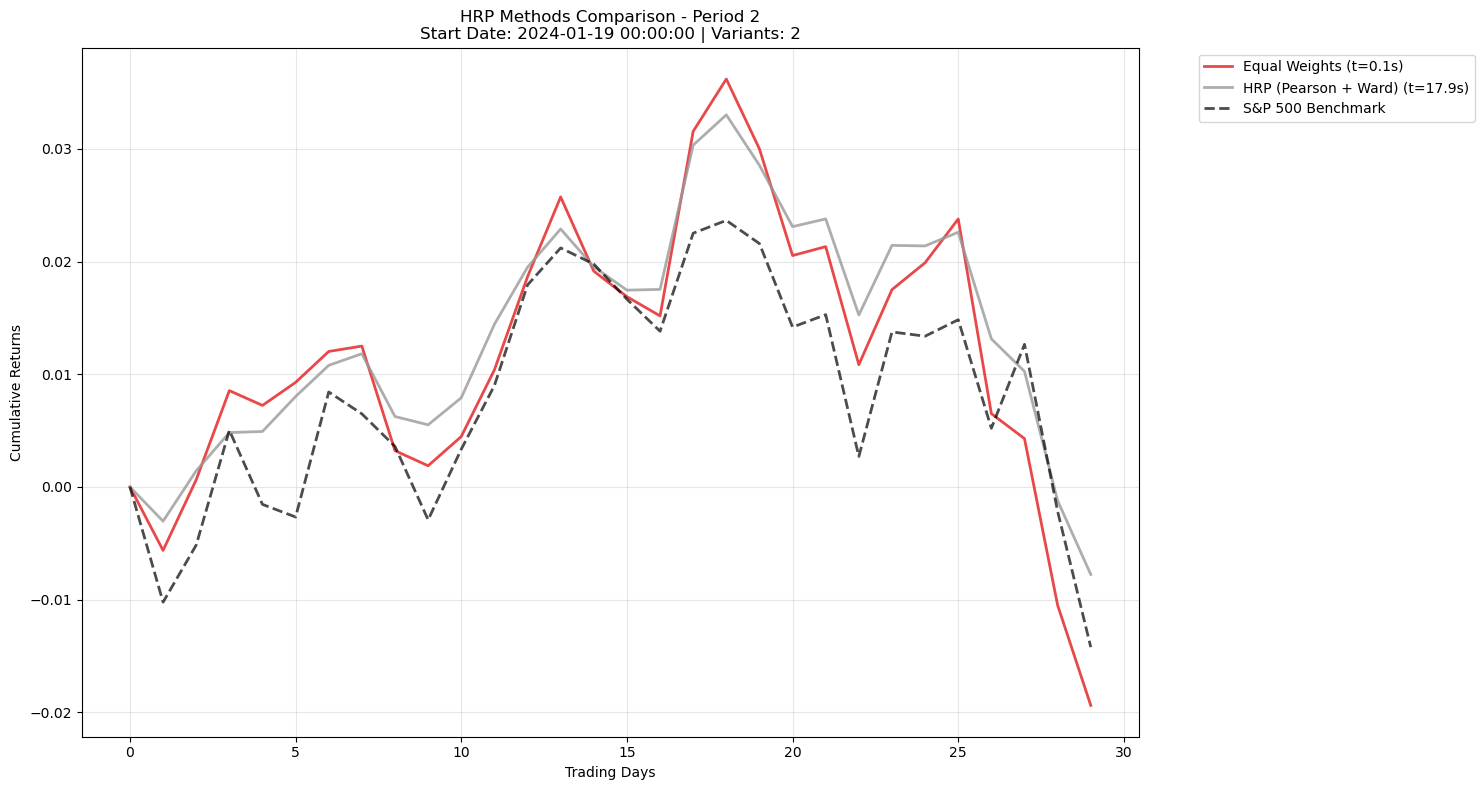

2025-12-09 20:50:04,438 - hrp_logger - INFO - Period 3: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,440 - hrp_logger - INFO - Period 3: Loaded HRP (Pearson + Ward) (exec_time: 17.88s)



Period 2 Summary:
--------------------------------------------------
Equal Weights            :  -0.0194 (  0.09s)
HRP (Pearson + Ward)     :  -0.0078 ( 17.88s)
Benchmark                :  -0.0142



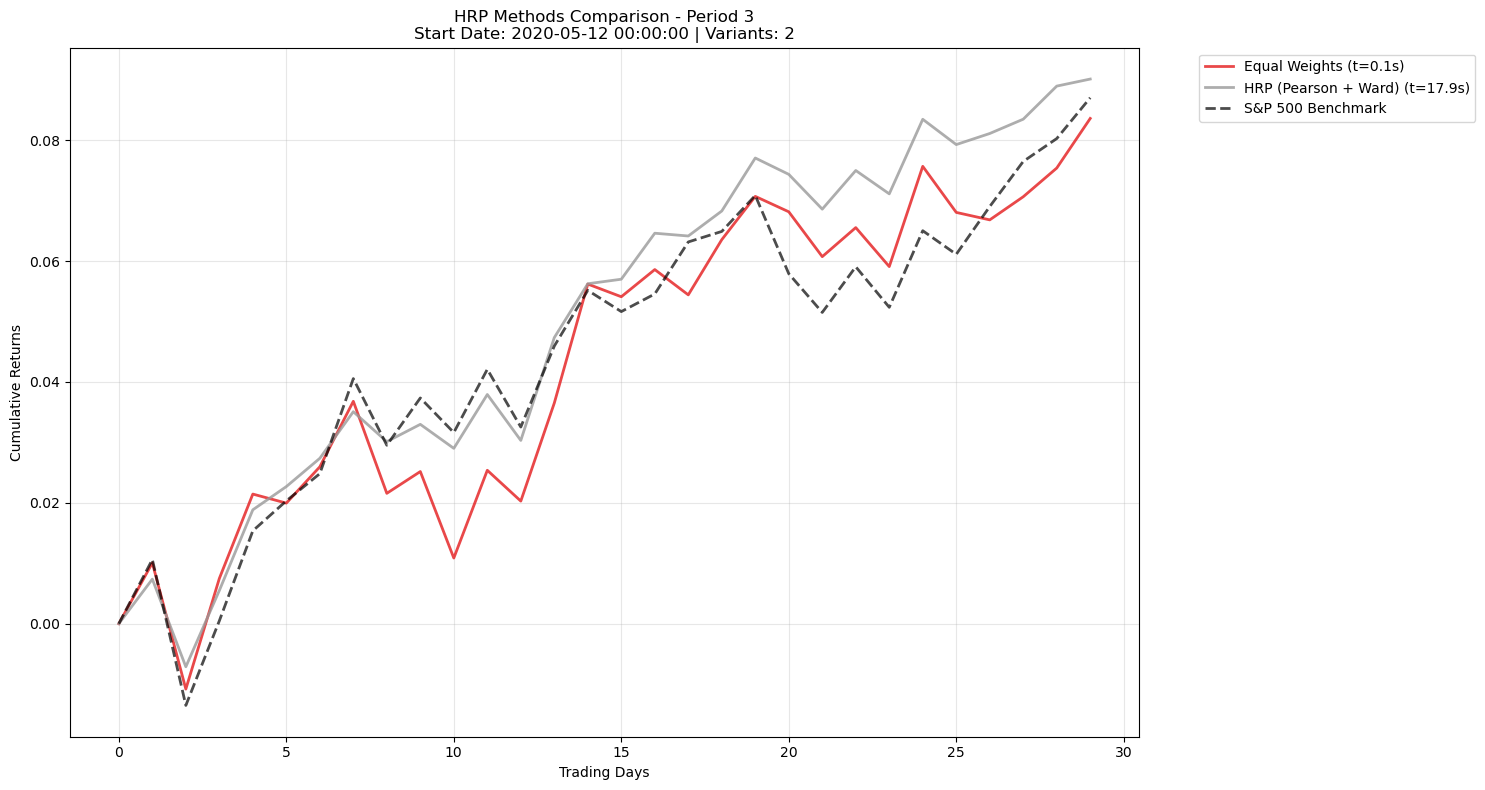

2025-12-09 20:50:04,532 - hrp_logger - INFO - Period 4: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,534 - hrp_logger - INFO - Period 4: Loaded HRP (Pearson + Ward) (exec_time: 18.18s)



Period 3 Summary:
--------------------------------------------------
Equal Weights            :   0.0836 (  0.09s)
HRP (Pearson + Ward)     :   0.0901 ( 17.88s)
Benchmark                :   0.0870



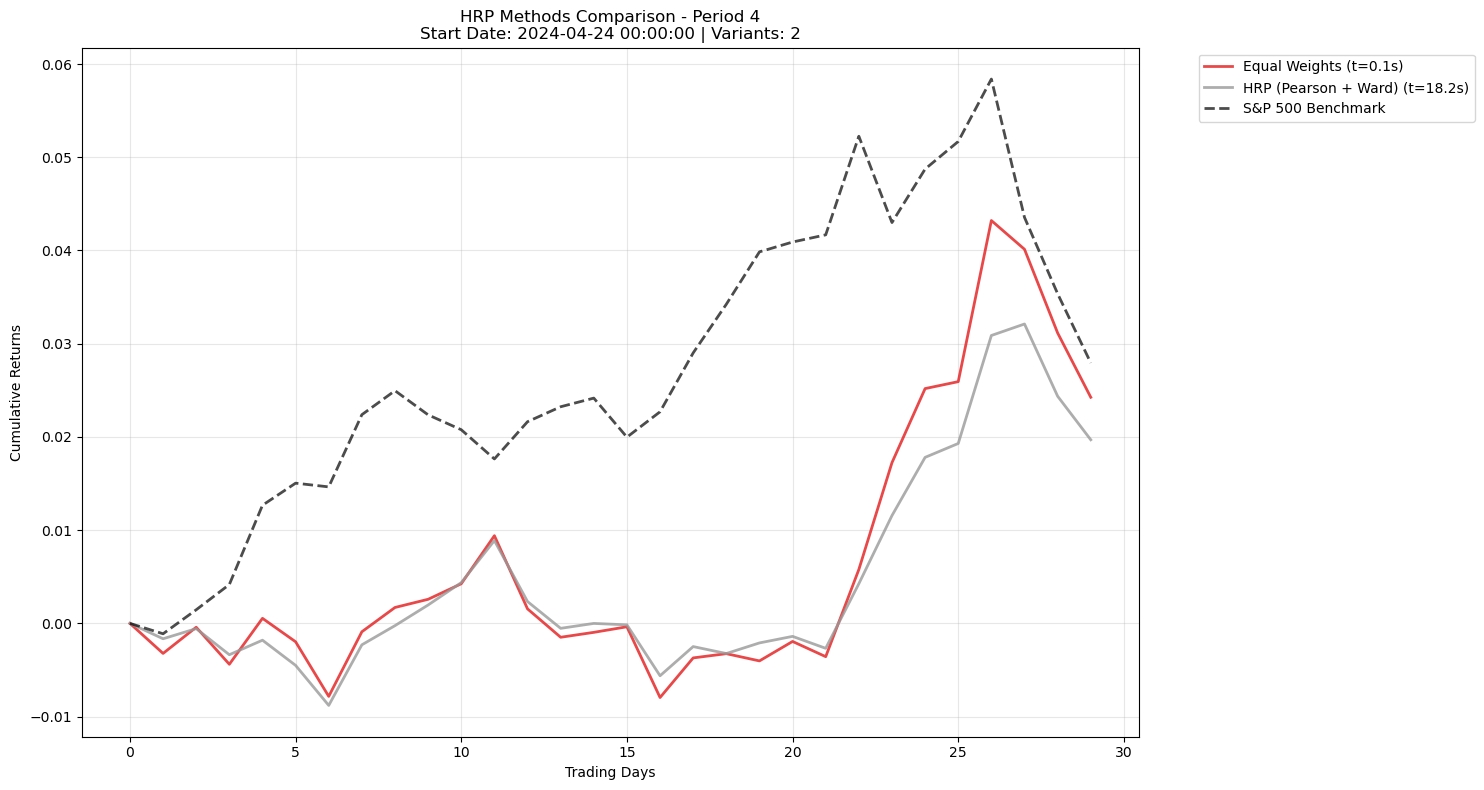

2025-12-09 20:50:04,632 - hrp_logger - INFO - Period 5: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,633 - hrp_logger - INFO - Period 5: Loaded HRP (Pearson + Ward) (exec_time: 18.06s)



Period 4 Summary:
--------------------------------------------------
Equal Weights            :   0.0243 (  0.09s)
HRP (Pearson + Ward)     :   0.0197 ( 18.18s)
Benchmark                :   0.0279



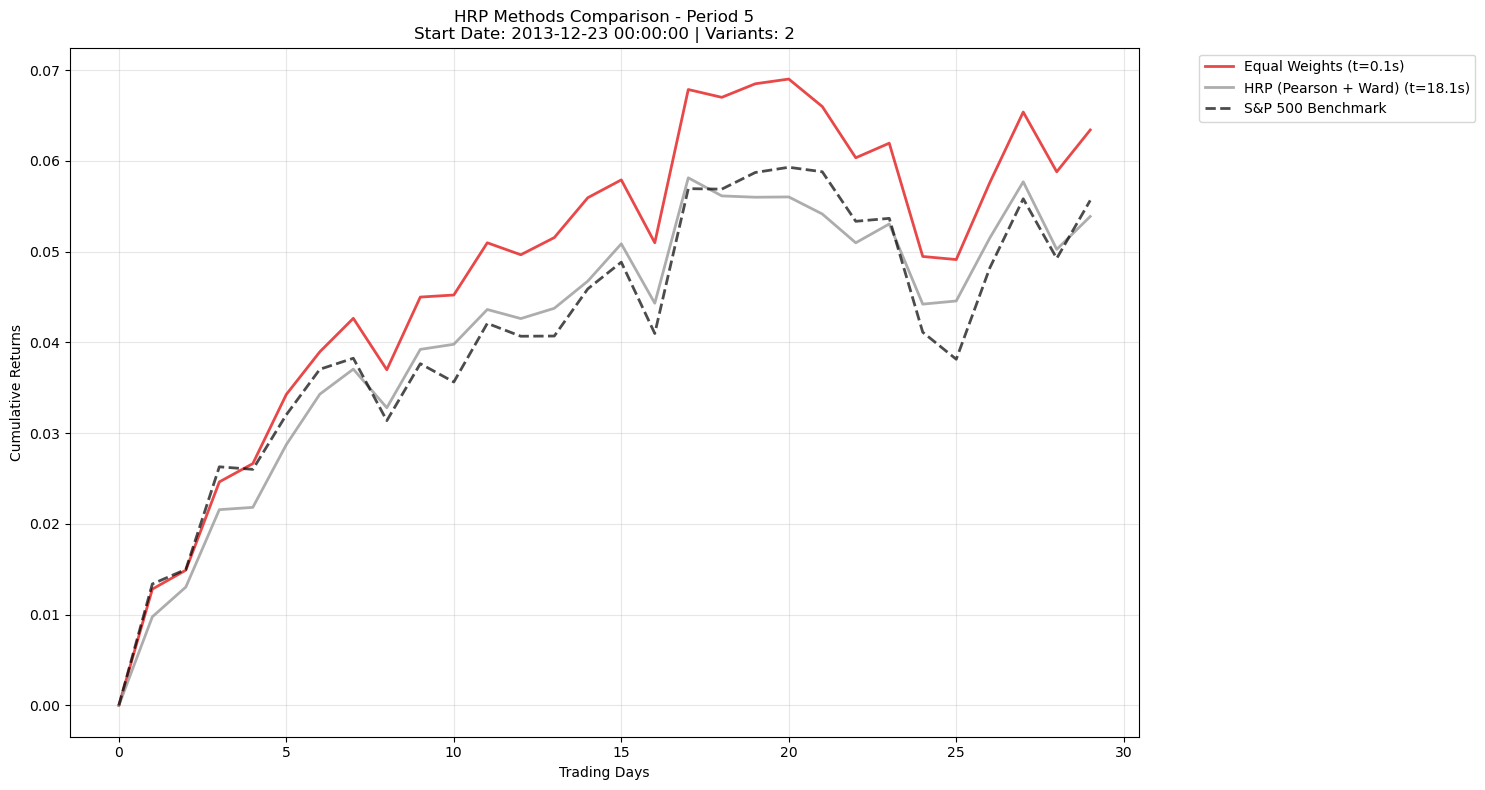

2025-12-09 20:50:04,730 - hrp_logger - INFO - Period 6: Loaded Equal Weights (exec_time: 0.09s)



Period 5 Summary:
--------------------------------------------------
Equal Weights            :   0.0634 (  0.09s)
HRP (Pearson + Ward)     :   0.0539 ( 18.06s)
Benchmark                :   0.0556



2025-12-09 20:50:04,732 - hrp_logger - INFO - Period 6: Loaded HRP (Pearson + Ward) (exec_time: 17.96s)


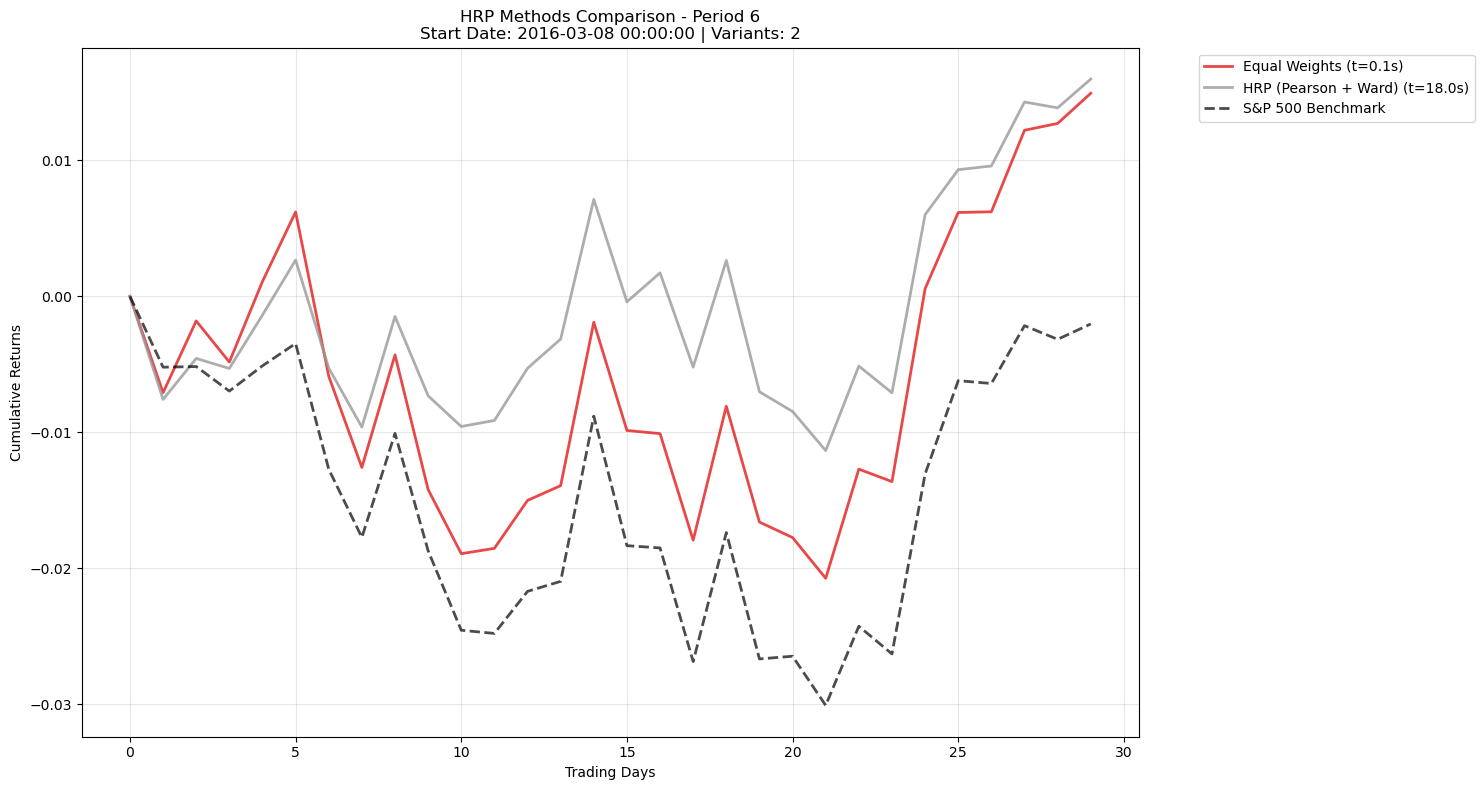

2025-12-09 20:50:04,804 - hrp_logger - INFO - Period 7: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,805 - hrp_logger - INFO - Period 7: Loaded HRP (Pearson + Ward) (exec_time: 18.03s)



Period 6 Summary:
--------------------------------------------------
Equal Weights            :   0.0149 (  0.09s)
HRP (Pearson + Ward)     :   0.0160 ( 17.96s)
Benchmark                :  -0.0020



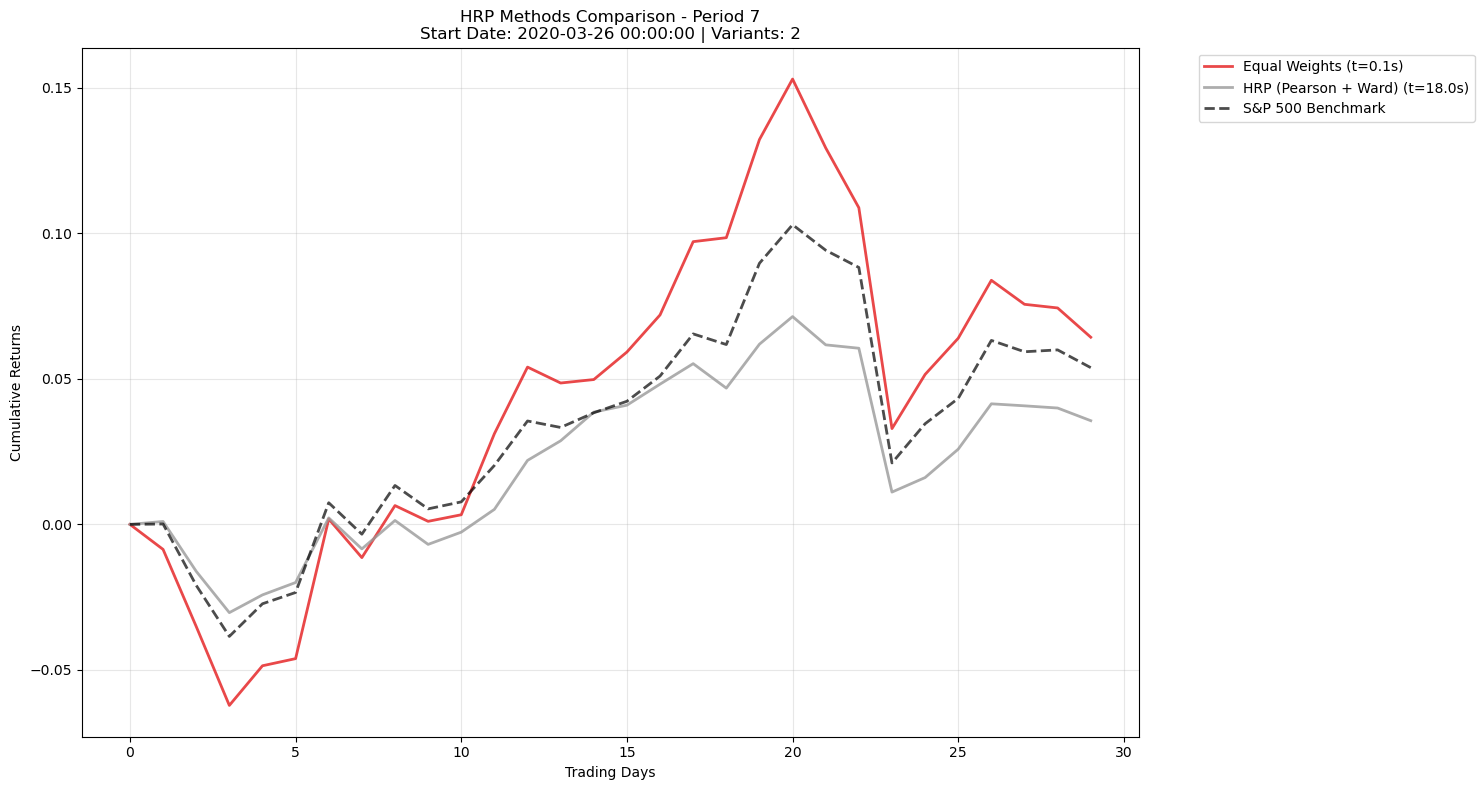

2025-12-09 20:50:04,878 - hrp_logger - INFO - Period 8: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,879 - hrp_logger - INFO - Period 8: Loaded HRP (Pearson + Ward) (exec_time: 17.53s)



Period 7 Summary:
--------------------------------------------------
Equal Weights            :   0.0643 (  0.09s)
HRP (Pearson + Ward)     :   0.0356 ( 18.03s)
Benchmark                :   0.0538



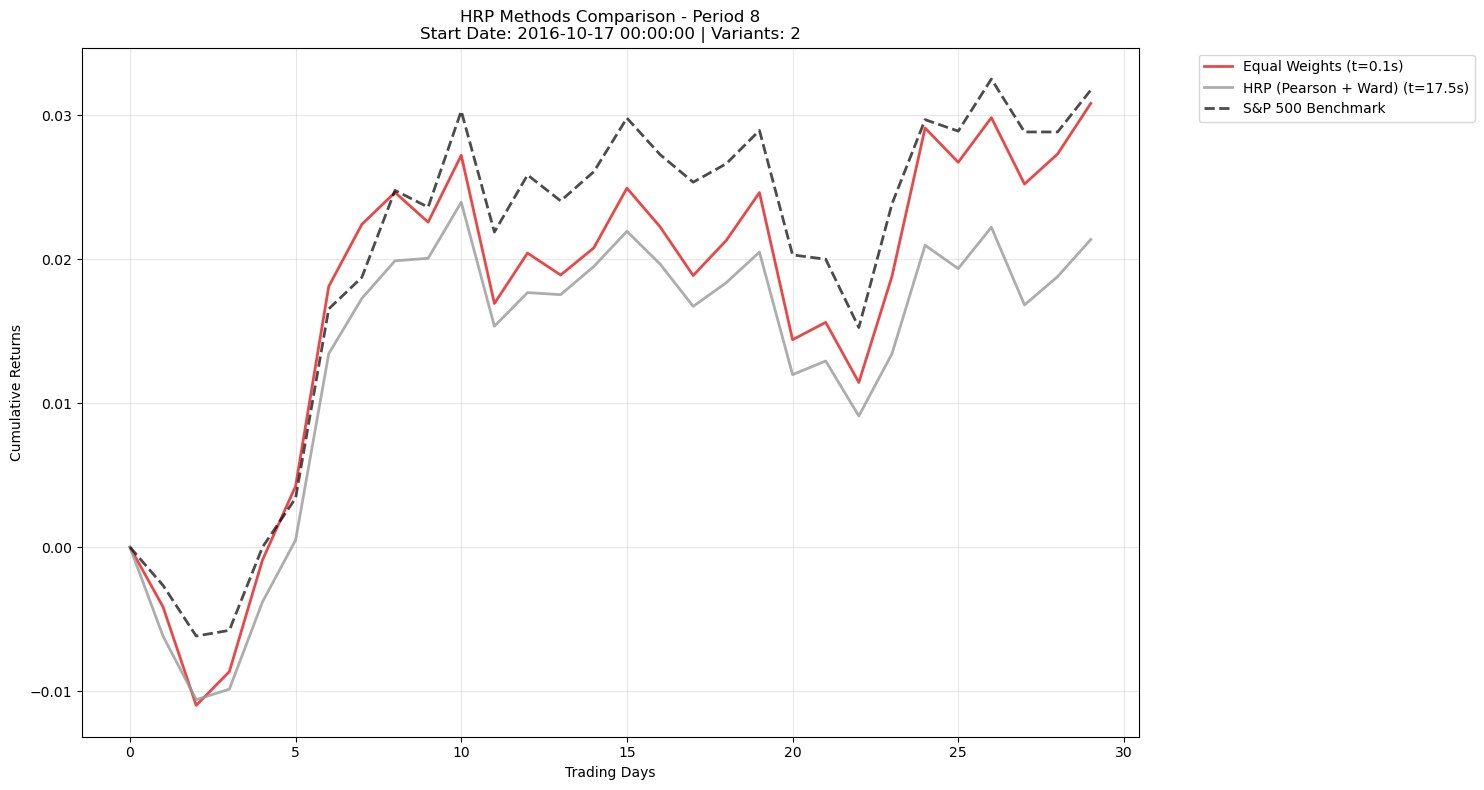

2025-12-09 20:50:04,950 - hrp_logger - INFO - Period 9: Loaded Equal Weights (exec_time: 0.09s)
2025-12-09 20:50:04,952 - hrp_logger - INFO - Period 9: Loaded HRP (Pearson + Ward) (exec_time: 18.35s)



Period 8 Summary:
--------------------------------------------------
Equal Weights            :   0.0308 (  0.09s)
HRP (Pearson + Ward)     :   0.0214 ( 17.53s)
Benchmark                :   0.0317



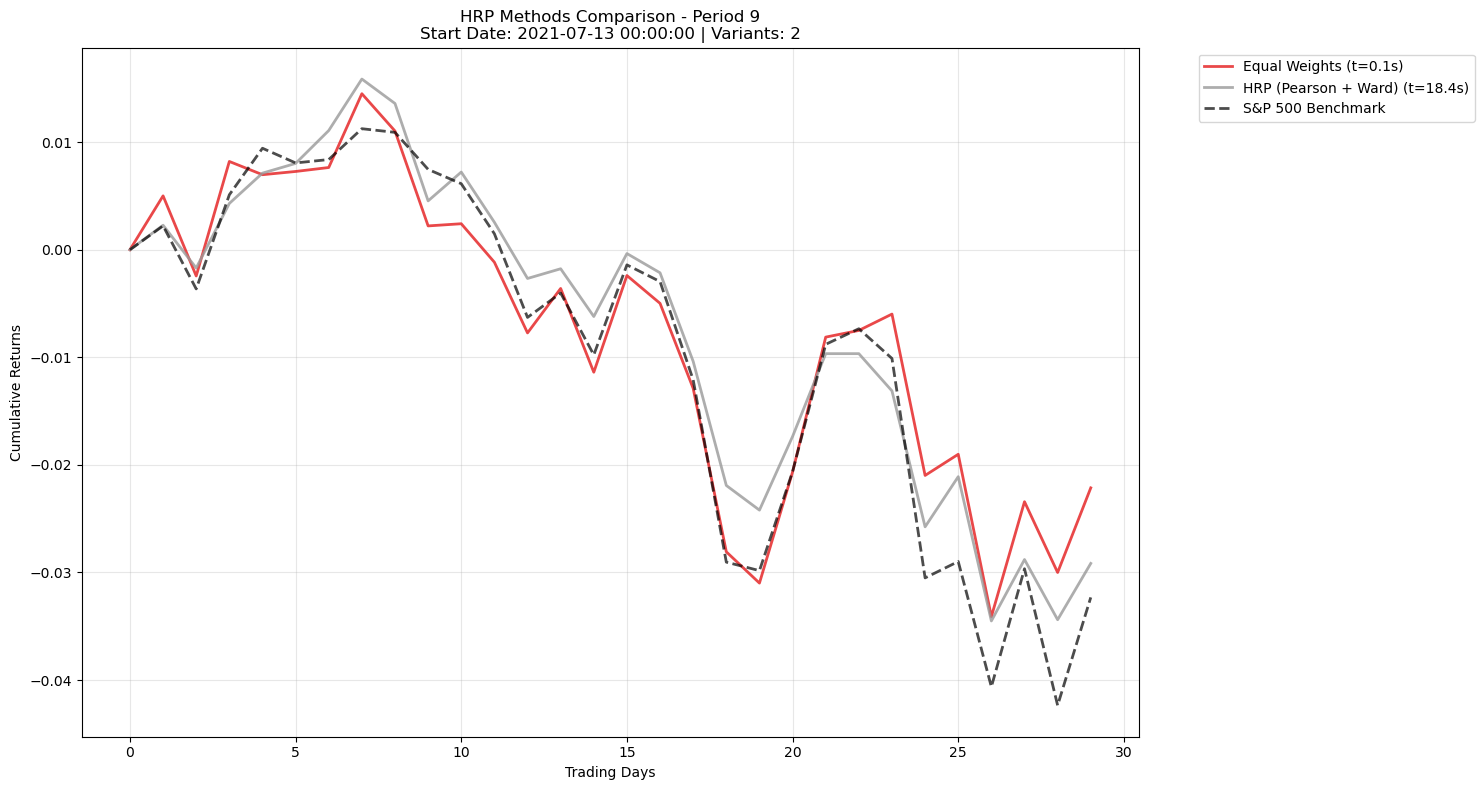


Period 9 Summary:
--------------------------------------------------
Equal Weights            :  -0.0221 (  0.09s)
HRP (Pearson + Ward)     :  -0.0292 ( 18.35s)
Benchmark                :  -0.0323


HRP PERFORMANCE SUMMARY


,Method,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,Equal Weights,10,0.0288,0.0344,-0.0221,0.0836,0.0906,0.0023,100.0
1,HRP (Pearson + Ward),10,0.0267,0.0316,-0.0292,0.0901,17.9510,0.2292,100.0



Performance Analysis:
--------------------------------------------------
Methods compared: 2
Best performer: Equal Weights (avg return: 0.0288)
Fastest method: Equal Weights (0.09s)


In [14]:
# Compare HRP variants and baseline
hrp_solvers = [
    {'path_template': '../../results/hrp/results_ew_{}.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/hrp/results_hrp_pearson_ward_{}.pkl', 'name': 'HRP (Pearson + Ward)'},
]

n_periods = parameters['n_periods']
multi_comparison(hrp_solvers, n_periods, "HRP Methods Comparison")

# Generate performance summary
print("\n" + "="*100)
print("HRP PERFORMANCE SUMMARY")
print("="*100)
summary_df = performance_summary(hrp_solvers, n_periods)
if not summary_df.empty:
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Method']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Method']} ({summary_df['Avg_Time'].min():.2f}s)")
else:
    print("No summary data available")